---

<div align="center">

<h1 style="color:#345682; font-weight:bold;">
:השפעות רגשיות של מלחמת חרבות ברזל<br> ניתוח חוויות הורים וילדים
</h1>

<h3 style="color:#345682">
Group Number 11
</h3>

<p style="font-size:16px;">
<b>Names of Students:</b><br>
Paz Ohayun<br>
Zack Netz<br>
Yamit Buskila
</p>
</div>

<div dir="rtl" style="text-align:right; font-size:16px;">
תרומת חברי הצוות לפרויקט – כל אחד מהחברים לקח חלק פעיל בכל שלבי העבודה – מהתכנון ועד לכתיבת המסקנות.  
שיתוף הפעולה בינינו התבסס על קבלת החלטות משותפת וחלוקת משימות באופן דינמי לפי צורך, כך שלמעשה כולם תרמו במידה שווה.
</div>

<hr>


<a id='top'></a>
<div align="center">

<!-- תמונה -->
<img src="https://github.com/yamitbuskila/exercises/blob/main/afbedd1d-11d9-4e6a-9789-e9c865b0e27e.png?raw=true" width="800"/>

<h3 style


---

<h2 style="color: #345682">Table of Contents:</h2>

<ol>
  <li>Data Preprocessing and Cleaning</li>
  <li>Getting to Know the Data</li>
  <li>Correlation Analysis</li>
  <li>Emotional Impact of Parental Soothing on Children</li>
  <li>Emotional Effects of Parental Self-Calming Strategies</li>
  <li>Emotional Impact of Parental News Consumption</li>
  <li>Appendices</li>
</ol>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt  
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from collections import Counter
from bidi.algorithm import get_display
import arabic_reshaper
from wordcloud import WordCloud
from collections import Counter
from IPython.display import display, HTML

In [2]:
df = pd.read_csv("new_data.csv") 
df.columns =df.columns.str.replace(r"\[.*?\]", "", regex=True).str.replace(r"^\d+\.\s*", "", regex=True).str.strip()                 

In [3]:
df_help = pd.read_csv("help_2.csv")
df_help.columns = df_help.columns.str.strip()
df_help["row"]=df_help["row"].str.replace(r"\[.*?\]", "", regex=True).str.replace(r"^\d+\.\s*", "", regex=True).str.strip()

<div dir='rtl'>
לפני שנתחיל נשנה את שמות העמודות כך שיהיה נוח וקריא להציג את הנתונים
</div>

In [4]:
mapping = {
    'חותמת זמן': 'timestamp',
    'מין הילד/ה': 'child_gender',
    'תאריך הלידה של הילד/ה': 'child_dob',
    'מספר הילדים במשפחה:': 'num_children',
    'סדר הלידה של הילד/ה המשתתף במחקר': 'child_birth_order',
    'המסגרת בה הילד/ה נמצא/ת:': 'child_setting',
    'ציינו את מקום מגוריכם הקבוע': 'home_residence',
    'ציינו היכן ילדיכם לומד בימים אלו': 'child_school_location',
    'ציינו את מקום המגורים של המשפחה כעת': 'current_residence',
    'מצב משפחתי :': 'marital_status',
    'מידת הדתיות של המשפחה': 'religiosity',
    'מי ממלא את השאלון מההורים:': 'respondent_parent',
    'גיל ההורה הממלא את השאלון:': 'parent_age',
    'ארץ לידה של ההורה הממלא את השאלון': 'parent_birth_country',
    'שנת עליה לארץ של ההורה הממלא את השאלון:': 'parent_aliyah_year',
    'השכלת ההורה הממלא את השאלון:': 'parent_education',
    'עבודת ההורה הממלא את השאלון:': 'parent_occupation',
    'היקף משרה בתקופה הנוכחית   (הורה הממלא את השאלון)': 'parent_job_pct_current',
    'היקף משרה לפני המלחמה (ההורה הממלא את השאלון):': 'parent_job_pct_before',
    'ציין/י מי מגויס במשפחה': 'family_mobilized',
    'גיל ההורה השני (שאינו ממלא את השאלון):': 'second_parent_age',
    'מין ההורה השני (שאינו ממלא את השאלון):': 'second_parent_gender',
    'ארץ לידה של ההורה השני (שאינו ממלא את השאלון):': 'second_parent_birth_country',
    'שנת עליה של ההורה השני:': 'second_parent_aliyah_year',
    'השכלת ההורה השני:': 'second_parent_education',
    'עבודת ההורה השני:': 'second_parent_occupation',
    'היקף משרה בתקופה המלחמה(ההורה השני):': 'second_parent_job_pct_war',
    'היקף המשרה לפני המלחמה (הורה שני):': 'second_parent_job_pct_before',
    'מספר החדרים בבית הקבוע': 'num_rooms',
    'מנסה לנחם או להרגיע אדם אחר שנמצא במצוקה.': 'to_comfort',
    'בדרך כלל אינו מודאג/ת או בוכה כשצופה בסרט עצוב בטלוויזיה.': 'low_distress_media',
    'לרוב אינו מודאג/ת כאשר חבר למשחק בוכה.': 'low_distress_peer_cry',
    'דואג כאשר אחת מהדמויות נפגעות או מתות בסיפור.': 'concern_story_char',
    'נוטה להראות אכפתיות, דאגה וטיפול בחיות.': 'care_animals',
    'מרגיש טוב כשדברים טובים קורים לדמות בסרט.': 'positive_story_emotion',
    'עשוי לשאול "מה קרה?" כשרואה מישהו שנמצא במצוקה.': 'ask_what_happened',
    'לפעמים יכול להציק לחיית מחמד שנמצאת ללא השגחה.': 'misbehave_pet',
    'מצטער בשביל אנשים אחרים שנפגעו, שהם חולים או שהם לא מאושרים.': 'empathic_sorrow',
    'מודאג כאשר הוא רואה חיה נפגעת.': 'concern_injured_animal',
    'כועס על הדמות הרעה בטלוויזיה שפוגעת בדמות אחרת.': 'anger_bad_char',
    'עשוי להציע צעצוע או ממתק לחבר שבוכה בעת משחק משותף, גם כשההורים לא מבקשים ממנו.': 'offer_toy',
    'מזהה מהר מה אחרים מרגישים.': 'quick_read_others',
    'עליז ושמח.': 'cheerful',
    'שינויים גדולים במצב רוח (קשה לחזות את מצבו הרגשי כי הוא עובר במהירות ממצב רוח חיובי לשלילי).': 'mood_swings',
    'מגיב באופן חיובי לגישושים ויוזמות חברתיות מצד מבוגרים.': 'positive_to_solicit',
    'עובר בקלות מפעילות אחת לפעילות אחרת; לא נהיה כועס, חרד, במצוקה או בהתרגשות יתר כאשר עובר מפעילות אחת לאחרת.': 'easy_transition',
    'מתאושש בקלות ממצב של מצוקה או סערת רגשות (לדוגמה לא נשאר כעוס, מצוברח, חרד או עצוב אחרי אירועים שעוררו רגשות חזקים/מצוקה).': 'quick_recover',
    'נהיה מתוסכל בקלות': 'easily_frustrated',
    'מגיב באופן חיובי לגישושים ויוזמות חברתיות מצד בני גילו.': 'positive_to_peer_social',
    'נוטה להתפרצויות כעס או התקפי זעם.': 'anger_outbursts',
    'מסוגל לדחות סיפוקים.': 'delay_gratification',
    'נהנה ממצוקה של אחרים (לדוגמה, צוחק כאשר מישהו אחר נפגע או נענש /  נראה כי נהנה להקניט אחרים).': 'enjoy_others_distress',
    'מסוגל לשלוט ברמת ההתרגשות שלו (לדוגמה: לא נסחף במצבי משחק הדורשים אנרגיה גבוהה; לא נרגש באופן מוגזם במצבים שאינם מתאימים).': 'emotional_control',
    'נוטה להיות בכייני עם מבוגרים או "להידבק" למבוגרים.': 'clingy',
    'נוטה להתפרצויות מוגזמות של אנרגיה והתלהבות.': 'overexcited',
    'מגיב בכעס להצבת גבולות מצד מבוגרים.': 'anger_to_limits',
    'מסוגל לומר מתי הוא מרגיש עצוב, כועס, או מפחד/חושש.': 'label_emotions',
    'נראה עצוב או אדיש.': 'appears_sad',
    'מתלהב/נמרץ בצורה מוגזמת כאשר הוא מנסה ליזום משחק עם אחרים.': 'overenthusiastic',
    'מראה מעט רגש (חסר הבעה רגשית; נראה שאינו נוכח מבחינה רגשית).': 'flat_affect',
    'מגיב באופן שלילי לגישושים ויוזמות חברתיות מצד בני גילו (לדוגמה, עשוי לדבר בטון כועס או להגיב באופן  מפוחד).': 'negative_to_peer_social',
    'הוא אימפולסיבי.': 'impulsive',
    'מראה אמפתיה כלפי אחרים; מפגין דאגה כאשר אחרים מצוברחים או במצוקה.': 'shows_empathy',
    'מפגין התנהגות נלהבת/נמרצת שאחרים חווים כמפריעה או פולשנית.': 'intrusive_behaviour',
    'מפגין רגשות שליליים מותאמים (פחד, כעס, תסכול, מצוקה) בתגובה להתנהגות תוקפנית, פולשנית או עוינת מצד בני גילו.': 'appropriate_negative_response',
    'מפגין רגשות שליליים כאשר הוא מנסה  ליזום משחק עם אחרים .': 'negative_when_initiating',
    'כאשר ילדי חש רגשות שליליים (כמו כעס, פחד, עצב), קשה לאחרים (לדוגמא, הורה) לגרום לו להרגיש טוב יותר ולהירגע': 'hard_to_sooth_negative',
    'כאשר ילדי שמח ומתרגש, קשה לאחרים (לדוגמא להורה) לגרום לו להיות בשקט': 'hard_to_sooth_positive',
    'כאשר אני רוצה שתהיה לי הרגשה יותר חיובית (כמו שמחה או שעשוע), אני חושב/ת על משהו אחר': 'mental_distraction_pos',
    'אני שומר/ת את הרגשות שלי לעצמי.': 'internalize_emotions',
    'כאשר אני רוצה להרגיש פחות רגש שלילי (כגון עצבות או כעס), אני חושב/ת על משהו אחר': 'mental_distraction_neg',
    'כאשר אני חש/ה רגשות חיוביים, אני נזהר/ת לא לבטא אותם.': 'control_by_not_expressing',
    'כאשר אני עומד/ת בפני מצב מלחיץ, אני גורם לעצמי לחשוב עליו בדרך שעוזרת לי להישאר רגוע/ה': 'distraction_to_positive',
    'אני שולט/ת ברגשות שלי על ידי כך שאני לא מבטא/ת אותם.': 'control_by_reappraisal',
    'כאשר אני רוצה שתהיה לי הרגשה יותר חיובית, אני משנה את הדרך בה אני חושב/ת על המצב': 'control_by_thought_change',
    'אני שולט/ת ברגשות שלי על ידי כך שאני משנה את הדרך בה אני חושב/ת על המצב בו אני נמצא/ת.': 'internalize_neg',
    'כאשר אני חש/ה רגשות שליליים, אני מקפיד/ה לא לבטא אותם': 'reappraisal_neg',
    'כאשר אני רוצה להרגיש פחות רגש שלילי, אני משנה את הדרך בה אני חושב/ת על המצב.': 'show_forgiveness',
    'מראה סלחנות למישהו ששבר חפץ אהוב': 'forgives_for_broken_object',
    'מצהיר/ה איזה יום יפה': 'express_beautiful_day',
    'מביע/ה חוסר שביעות רצון מהתנהגות של משהו אחר.': 'express_dissatisfaction',
    'משבח/ת מישהו עבור עבודה טובה.': 'praise_good',
    'מביע/ה כעס כלפי חוסר זהירות של מישהו.': 'anger_at_careless',
    'בוכה אחרי וויכוח לא נעים.': 'cry_after_argument',
    'מתעלם/ת מצרכים של אחרים.': 'ignore_others_needs',
    'מראה חוסר חיבה כלפי מישהו.': 'show_coldness',
    'נשבר/ת  כשיש מצב של מתח': 'break_under_stress',
    'מביע/ה התרגשות כלפי תוכניות לעתיד של מישהו': 'express_future_excitation',
    'מראה התפעלות ממישהו.': 'show_impressed',
    'מתעצבן/ת מדברים קטנים.': 'get_annoyed_small',
    'מחבק/ת באופן ספונטני בן משפחה.': 'spontaneous_hug',
    'מציע/ה לעשות טובה למישהו': 'offer_favor',
    'מראה כמה אני עצבני אחרי יום רע.': 'show_after_bad_day',
    'מביע/ה אמפתיה כלפי בעיות של אחרים': 'express_empathy_problems',
    'מאיים/ת על אחרים': 'threaten_others',
    'מפתיע/ה מישהו עם מתנה קטנה או טובה': 'surprise_with_gift',
    'מביע/ה אכזבה כשמשהו לא מצליח.':'express_disappointment',
    'מביע/ה חיבה עמוקה או אהבה כלפי מישהו.': 'express_deep_affection',
    'בתקופה זו האם ילדך נרגע בקלות כאשר חווה רגשות שליליים?': 'easy_regulate_negative',
    'האם ילדך נרדם בקלות בלילה': 'easy_sleep',
    'האם ילדך מתעורר מחלומות ופחדים באמצע הלילה?': 'nightmares',
    'האם ילדך נרגע בקלות כאשר חווה רגשות חיוביים?': 'easy_regulate_positive',
    'כיצד את/ה עוזרים לילדכם להירגע כאשר חווה רגשות שליליים (פחד, כעס)? אנא פרטו': 'help_child_relax',
    'האם ילדכם מביע פחד וחשש מוגברים שנשמעת אזעקה': 'alarm_fear',
    'האם חלה רגרסיה בהתנהגות של ילדיכם, פרטו': 'regression_behavior',
    'מהם הדרכים בהם את/ה עוזרים לעצמכם להירגע ולחוש וויסות רגשי גבוה יותר? אנא פרטו': 'self_relax_strategies',
    'ציינו כמה פעמים אתם מתעדכנים בחדשות': 'news_freq', 
    'מביע/ה אמפתיה כלפי בעיות של אחרים':'express_empathy_problems',
    'מפתיע/ה מישהו עם מתנה קטנה או טובה':'surprise_with_gift',
    'מביע/ה אכזבה כשמשהו לא מצליח.':'express_disappointment',
    'מביע/ה חיבה עמוקה או אהבה כלפי מישהו.':'express_deep_affection',
    'כיצד את/ה עוזרים לילדכם להירגע כאשר חווה רגשות שליליים (פחד, כעס)? אנא פרטו': 'help_child_relax',
    'כיצד היית/ה מגדיר/ה את האווירה בבית בתקופה זו? אנא פרטו':'home_atmosphere',
    'מהם הדרכים בהם את/ה עוזרים לעצמכם להירגע ולחוש וויסות רגשי גבוה יותר? אנא פרטו': 'self_relax_strategies',
    'האם יש פצועים/הרוגים/חטופים מקרב משפחתך או חבריך הקרובים.':'casualties_close',
    'האם ישנה עליה בהתפרצויות הזעם, בכי, רגשות שליליים של ילדיכם (הילד המשתתף במחקר)?':'inc_neg_emotions'
}
df.rename(columns=mapping, inplace=True)
df_help['row'] = df_help['row'].replace(mapping)

<div dir='rtl'>
במהלך כל העבודה עבדנו עם דאטה בעברית ועל כן השתמשנו בפונקצייה אשר מטרתה היא לסדר את הטקסט כך שיהיה קריא בעברית, הפונקציה נעזרת בספרייה שייבאנו bidi.algorithm.
</div>

In [5]:
def reshape_text(text):
    try:
        return get_display(arabic_reshaper.reshape(text))
    except:
        return text

---

<h2 style="color: #345682">🛠️ Data Preprocessing and Cleaning</h2>

<div dir='rtl'>
  <strong style="font-size: 18px;">הפקת עמודות חדשות מנתונים קיימים:</strong>
</div>


<div dir='rtl'>
יצירת עמודות גיל וקבוצות גיל עבור ההורים והילדים
</div>

In [6]:
df['date'] = pd.to_datetime(df['child_dob'], format='%d/%m/%Y', dayfirst=True, errors='coerce')
df['age_child'] = (pd.to_datetime('2025-04-30') - df['date']).dt.days // 365
df["age_group_child"] = pd.cut(df["age_child"],bins=[0, 9, 16], labels=[1, 2],right=False) #הילד שלא נמצא בטווח לא יקבל ערך 
df["age_group_child_label"] = df["age_group_child"].map({1:"0–8",2:"9–15"}) #הילד שלא נמצא בטווח לא יקבל ערך 

In [7]:
df["parent_age_group"] = pd.cut(df["parent_age"],bins=[23, 34, 44, 55],labels=[1, 2, 3],right=True)
df["second_parent_age_group"] = pd.cut(df["second_parent_age"],bins=[23, 34, 44, 55],labels=[1, 2, 3],right=True)

<div dir='rtl'>
הוספת עמודה חדשה (Gender) לטבלה, אשר מאחדת את ערכי העמודה המקורית child_gender לשתי קטגוריות אחידות: 'Male' ו־'Female'.
</div>

In [8]:
df.loc[82,"child_gender"] = 'Female'
df["Gender"] = df["child_gender"].astype(str)

In [9]:
mapping_gender = {
    'זכר': 'Male',
    "1": 'Male',
    'נקבה': 'Female',
    "2" : 'Female'
}
df["Gender"] = df["child_gender"].replace(mapping_gender)

<div dir='rtl'>
יצירת עמודה אחידה אשר תייצג את מגדר ההורה אשר ענה על השאלון וההורה הנוסף.
</div>

In [10]:
df["Gender_parent_encoded"] = df["respondent_parent"].map({"אבא": 1, "אמא": 2})
df["second_parent_gender_encoded"] = df["second_parent_gender"].map({"נקבה": 2,"זכר": 1,"אין הורה נוסף": 0})

In [11]:
df["Gender_parent_TXT"] = df["respondent_parent"].map({"אבא": "Male", "אמא": "Female"})
df["second_parent_gender_TXT"] = df["second_parent_gender"].map({"נקבה": "Female", "זכר": "Male", "אין הורה נוסף": None})

<div dir='rtl'>
המרת ערכים בעמודת current_residence לקטגוריות של דיור קבוע וזמני, במטרה להבין כמה מהאוכלוסיית המחקר פונתה בעקבות המלחמה.
</div>

In [12]:
df["current_residence"] = df["current_residence"].astype(str).str.strip()
mapping_residence={
    'בית המגורים הקבוע (בבעלותי או בשכירות)': 'Permanent Residence',
    'מתארחים אצל חברים או משפחה': 'Temporary Housing',
    'בית מלון': 'Temporary Housing',
    'דירה שכורה או דירה זמנית (מפונים)': 'Temporary Housing'
}
df['Family’s Current Residence'] = df['current_residence'].replace(mapping_residence)

<div dir='rtl'>
הוספת עמודה אשר מטרתה להבין לכמה מהאוכלוסיית המחקר יש משפחה גרעינית מגוייסת
</div>

In [13]:
mapping_recruitment={
    'בן משפחה קרוב מגויס (ילדים, הורים, אחים)': 'Nuclear Family Recruited',
    'בן/בת זוגי': 'Nuclear Family Recruited',
    'אני (ממלא השאלון)': 'Nuclear Family Recruited',
    'אף אחד מבני משפחתי הקרובה אינו מגוייס': 'No One in the Nuclear Family is Recruited'
}
df['Recruitment Status in Family'] = df['family_mobilized'].replace(mapping_recruitment)

<div dir='rtl'>
יצירת עמודה אשר תייצג את מיקום הילד ביחס למספר הילדים המשפחה:
</div>

In [14]:
mapping_child_order = {
    'ראשון': 1,
    'שני': 2,
    'שלישי': 3,
    'חמישי': 5,
    'רביעי':4,
    'שלישי, רביעי':0,
    'אחר':0,
}
df["child_birth_order_num"]=df["child_birth_order"].replace(mapping_child_order).astype(int)
df["the_place_in_fam"] = df["child_birth_order_num"].astype(str) + "/" + df["num_children"].astype(str)

C:\Users\lihin\AppData\Local\Temp\ipykernel_74816\2946910252.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["child_birth_order_num"]=df["child_birth_order"].replace(mapping_child_order).astype(int)


<div dir='rtl'>
על מנת להבין את גודל השינוי בהיקף המשרות של ההורים לפני ואחרי המלחמה, הוספנו עמודה שמציגה את שינוי אחוז היקף המשרה בעקבות המלחמה עבור כל הורה.

- שינוי **שלילי** יעיד על ירידה באחוז המשרה  
- שינוי **חיובי** יעיד על עלייה באחוז המשרה  
- שינוי **0** יעיד על המשרה לא השתנתה

</div>


In [15]:
mapping_job_pct = {
    '25%': 25,
    '50%': 50,
    '75%': 75,
    '100%': 100,
    'יותר מ100%': 150,
    'לא עובד/ת': 0,
    'חופשה ללא תשלום': 0,
    '100%, יותר מ100%': 125
}
df["parent_job_pct_before_num"]=df["parent_job_pct_before"].replace(mapping_job_pct).astype("Int64")

C:\Users\lihin\AppData\Local\Temp\ipykernel_74816\2089134958.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["parent_job_pct_before_num"]=df["parent_job_pct_before"].replace(mapping_job_pct).astype("Int64")


In [16]:
mapping_job_pct_current = {
    '25%': 25,
    '50%': 50,
    '75%': 75,
    '100%': 100,
    '75%, 100%': 88,
    'יותר מ100%': 150,
    'לא עובד/ת': 0.0,
    'חופשה ללא תשלום': 0.0,
    'לא עובד/ת, חופשה ללא תשלום': 0.0
}
df["parent_job_pct_current_num"]=df["parent_job_pct_current"].replace(mapping_job_pct_current).astype("Int64")

C:\Users\lihin\AppData\Local\Temp\ipykernel_74816\906184549.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["parent_job_pct_current_num"]=df["parent_job_pct_current"].replace(mapping_job_pct_current).astype("Int64")


In [17]:
mapping_second_parent_job_pct = {
    '25%': 25,
    '50%': 50,
    '75%': 75,
    '100%': 100,
    '75%, 100%': 100,
    'יותר מ100%': 150,
    'לא עובד/ת': 0,
    'חופשה ללא תשלום': 0
}

df["second_parent_job_pct_war_num"] =df["second_parent_job_pct_war"].replace(mapping_second_parent_job_pct).astype("Int64")

C:\Users\lihin\AppData\Local\Temp\ipykernel_74816\351257971.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["second_parent_job_pct_war_num"] =df["second_parent_job_pct_war"].replace(mapping_second_parent_job_pct).astype("Int64")


In [18]:
mapping_second_parent_job_pct= {
    '25%': 25,
    '50%': 50,
    '75%': 75,
    '100%': 100,
    'יותר מ100%': 150,
    '100%, יותר מ100%': 150,
    'לא עובד/ת': 0,
    'חופשה ללא תשלום': 0,
    'לא עובד/ת, 100%': 100,
    'לא עובד/ת, יותר מ100%': 150
}
df["second_parent_job_pct_before_num"] =df["second_parent_job_pct_before"].replace(mapping_second_parent_job_pct).astype("Int64")

C:\Users\lihin\AppData\Local\Temp\ipykernel_74816\1516184521.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["second_parent_job_pct_before_num"] =df["second_parent_job_pct_before"].replace(mapping_second_parent_job_pct).astype("Int64")


In [19]:
df["job_change_parent"] = df["parent_job_pct_current_num"] - df["parent_job_pct_before_num"]
df["job_change_second_parent"] = df["second_parent_job_pct_war_num"] - df["second_parent_job_pct_before_num"]

In [20]:
bins = [-float('inf'), -1, 1, float('inf')]
labels = ["[-150-0]","[0]","[0-150]"]
df["job_change_parent_binned"] = pd.cut(df["job_change_parent"], bins=bins, labels=labels)
df["job_change_second_parent_binned"] = pd.cut(df["job_change_second_parent"], bins=bins, labels=labels)

<div dir='rtl'>
בניית עמודה חדשה המבוססת על עמודת שעות העבודה של ההורים בזמן המלחמה המחלקת את ערכי השעות לשלוש קבוצות בעלות טווחים שווים:

- 0–50 שעות 
- 50–100 שעות 
- 100–150 שעות

</div>


In [21]:
df["job_hours_grouped_parent"] = pd.cut(df["parent_job_pct_current_num"],bins=[0, 50, 100, 150],labels=["0–50", "51–100", "101–150"],right=True,include_lowest=True)
df["job_hours_grouped_second_parent"] = pd.cut(df["second_parent_job_pct_war_num"],bins=[0, 50, 100, 150],labels=["0–50", "51–100", "101–150"],right=True,include_lowest=True)

<div dir='rtl'>
  <strong style="font-size: 17px;">התאמת מבנה העמודות:</strong>
  <br><br>
  בחלק זה נעשה שימוש בקובץ אקסל נוסף, שבו מופיעה עמודה עם שמות כל העמודות מהקובץ המקורי. 
  בעזרת יצירת רשימות מותאמות לכל תת-משימה, בוצעו ההתאמות הבאות:
  <ul>
    <li><strong>המרה של עמודות טקסטואליות לעמודות מספריות אחידות</strong>
    <li><strong>היפוך טווחים</strong> – בעמודות שבהן ערך גבוה סימל עמדות שליליות, בוצע היפוך כך שערך נמוך יסמל שליליות וגבוה – חיוביות.</li>
  </ul>
</div>


In [22]:
slice_0 = df_help.iloc[42:68]
turn_cols = slice_0[slice_0["turn"].str.lower().str.contains("turn", na=False)]["row"].tolist()

In [23]:
mapping_turn_cols = {
    "אף פעם לא": 7,
    "לפעמים": 6,
    "לעיתים קרובות": 4,
    "כמעט תמיד": 2,
    "תמיד": 0
}
df[turn_cols] = df[turn_cols].replace(mapping_turn_cols).astype(int)

C:\Users\lihin\AppData\Local\Temp\ipykernel_74816\447954763.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[turn_cols] = df[turn_cols].replace(mapping_turn_cols).astype(int)


In [24]:
hip_cols = df_help[df_help["turn"].str.lower().str.contains("turn", na=False)]["row"].tolist()
df[hip_cols] = 7 - df[hip_cols]

In [25]:
slice_1 = df_help.iloc[42:68]
cols_to_exclude = slice_1[slice_1["turn"].str.lower().str.contains("turn", na=False)]["row"].tolist()

In [26]:
mapping_cols_to_change = {
    'תמיד': 7,
    'כמעט תמיד': 6,
    'לעיתים קרובות': 5,
    'לפעמים': 3,
    'אף פעם לא': 0
}
cols_to_change = df.columns[42:68].difference(cols_to_exclude)
df[cols_to_change] = df[cols_to_change].replace(mapping_cols_to_change).astype(int)  #ההחלפה עצמה רק על מה שעשינו פה 

C:\Users\lihin\AppData\Local\Temp\ipykernel_74816\1169794411.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[cols_to_change] = df[cols_to_change].replace(mapping_cols_to_change).astype(int)  #ההחלפה עצמה רק על מה שעשינו פה


In [27]:
df.iloc[:, 29:68] = df.iloc[:, 29:68].astype(int)

In [28]:
mapping_col = {
    'מאוד לא מסכים 1': 1,
    '1': 1,
    '2': 2,
    '3': 3,
    '4': 4,
    '5': 5,
    'ניטרלי 4': 4,
    '6': 6,
    '7': 7,
    'מאוד מסכים 7': 7
}

df.iloc[:, 68:78] = df.iloc[:, 68:78].replace(mapping_col).astype(int)
df.iloc[:, 68:78] = df.iloc[:, 68:78].astype(int)

C:\Users\lihin\AppData\Local\Temp\ipykernel_74816\2628505316.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.iloc[:, 68:78] = df.iloc[:, 68:78].replace(mapping_col).astype(int)


In [29]:
columns_to_convert = [
    "mental_distraction_pos",
    "internalize_emotions",
    "mental_distraction_neg",
    "control_by_not_expressing",
    "distraction_to_positive",
    "control_by_reappraisal",
    "control_by_thought_change",
    "internalize_neg",
    "reappraisal_neg",
    "show_forgiveness"]

for column in columns_to_convert:
    df[column] = df[column].astype(int)

In [30]:
mapping_col_2 = {
    '1': 1,
    '1. אף פעם לא': 1,
    '2': 2,
    '2. לפעמים': 2,
    '3': 3,
    '3. לעיתים קרובות': 3,
    '4': 4,
    '4. כמעט תמיד': 4
}
df.iloc[:, 100:104] =df.iloc[:, 100:104].replace(mapping_col_2).astype(int)
df["alarm_fear_child"]=df["alarm_fear"].replace(mapping_col_2).astype(int)

C:\Users\lihin\AppData\Local\Temp\ipykernel_74816\457449503.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.iloc[:, 100:104] =df.iloc[:, 100:104].replace(mapping_col_2).astype(int)
C:\Users\lihin\AppData\Local\Temp\ipykernel_74816\457449503.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["alarm_fear_child"]=df["alarm_fear"].replace(mapping_col_2).astype(int)


In [31]:
columns_to_convert_2 = ["easy_regulate_negative","easy_sleep","nightmares","easy_regulate_positive"]
for column in columns_to_convert_2:
    df[column] = df[column].astype(int)

<div dir='rtl'>
  <span style="font-size: 18px; font-weight: 600;">נרמול עמודות:</span>
</div>
<div dir='rtl'>
בשלב זה בוצע נרמול לכלל העמודות המספריות אשר אינן בינאריות במטרה לאחד את טווח הערכים שלהן ולמנוע השפעות הנובעות מטווחים שונים בין עמודות.
</div>

In [32]:
columns_to_normalize2 = df.columns[29:98].tolist()+["easy_regulate_positive"]+["easy_sleep"]+["nightmares"]+["easy_regulate_negative"]
df_norm = df[columns_to_normalize2].apply(lambda x: (x - x.min()) / (x.max() - x.min()))
df.drop(columns=columns_to_normalize2, inplace=True) #משנה את הקובץ המקורי
df = pd.concat([df, df_norm], axis=1)

<div dir='rtl'>
  <span style="font-size: 18px; font-weight: 600;">בניית מדדי סיכום רגשיים מהנתונים הגולמיים:</span>
</div>
<div dir='rtl'>
בשלב הלה, ביצענו ממוצע בין עמודות המתארות את רגשותיהם של ההורים והילדים , תוך הבחנה בין רגשות חיוביים ושליליים וחלוקה של הנתונים לקבוצות הבאות:
    
1. Child Empathy – אמפתיה של הילד
2. Child Emotion Regulation - Positive – ויסות רגשות חיובי של הילד
3. Child Emotion Regulation - Negative – ויסות רגשות שלילי של הילד
4. Parent Emotion Regulation - Reappraisal –הערכה מחודשת כאסטרטגיה לוויסות רגשי - הורים 
5. Parent Emotion Regulation - Suppression – הדחקה כאסטגריה לוויסות רגשי - הורים 
6. Parent's Emotional Expressiveness - Positive – הבעה רגשית חיובית של ההורה
7. Parent's Emotional Expressiveness - Negative – הבעה רגשית שלילית של ההורה

<br>
לאחר חישוב הממוצע של הקבוצות עבור כל שורה, נוכל לעבוד עם נתונים אלו בהמשך הפרוייקט.
</div>

In [33]:
slice_1 = df_help.iloc[44:70]
positive_topics1 = slice_1[slice_1["type"].str.lower().str.contains("positive", na=False)]["row"].tolist()
negative_topics1 = slice_1[slice_1["type"].str.lower().str.contains("negative", na=False)]["row"].tolist()

In [34]:
df["child emotion regulation-positive"] = df[positive_topics1].mean(axis=1).round(3)
df["child emotion regulation-negative"] = df[negative_topics1].mean(axis=1).round(3)

In [35]:
slice_2 = df_help.iloc[70:80]
reappraisal_topics1 = slice_2[slice_2["type"].str.lower().str.contains("reappraisal", na=False)]["row"].tolist()
suppression_topics1 = slice_2[slice_2["type"].str.lower().str.contains("suppression", na=False)]["row"].tolist()

In [36]:
df["parent emotion regulation-reappraisel"] = df[reappraisal_topics1].mean(axis=1).round(3)
df["parent emotion regulation-suppression"] = df[suppression_topics1].mean(axis=1).round(3)

In [37]:
slice_3 = df_help.iloc[79:100]
positive_topics2 = slice_3[slice_3["type"].str.lower().str.contains("positive", na=False)]["row"].tolist()
negative_topics2 = slice_3[slice_3["type"].str.lower().str.contains("negative", na=False)]["row"].tolist() 

In [38]:
df["parents emotional expersivness-positive"] = df[positive_topics2].mean(axis=1).round(3)
df["parents emotional expersivness-negative"] = df[negative_topics2].mean(axis=1).round(3)

In [39]:
columns_empathy = df_help.iloc[31:44]["row"].tolist()
df["child_empathy"] = df[columns_empathy].mean(axis=1).round(3)

In [40]:
slice_1 = df_help.iloc[44:70]
positive_topics1 = slice_1[slice_1["type"].str.lower().str.contains("positive", na=False)]["row"].tolist()
negative_topics1 = slice_1[slice_1["type"].str.lower().str.contains("negative", na=False)]["row"].tolist()

In [41]:
df["child emotion regulation-positive"]=df[positive_topics1].mean(axis=1).round(1)
df["child emotion regulation-negative"]=df[negative_topics1].mean(axis=1).round(1)

<div dir='rtl'>
  <span style="font-size: 18px; font-weight: 600;">עיבוד תשובות פתוחות:</span>
</div>
<div dir='rtl'>
  חלק מהשאלות בשאלון הוגדרו כתשובות פתוחות, ולצורך עיבוד הנתונים היה צורך להמיר תשובות אלה לקטגוריות אחידות.
  <br>
  לשם כך בוצעה המרה באמצעות שתי שיטות: בחלק מהמקרים ההמרה בוצעה באופן ידני, ובחלק אחר נכתבה פונקציה שהתבססה על מילון מונחים.
  <br>
  המילון הכיל רשימות של ביטויים חוזרים, כאשר כל מפתח מייצג שיטת הרגעה כללית והערכים כללו וריאציות נפוצות שעלו בתשובות המשתתפים.
</div>


In [42]:
indicator_words_child = {"חיבוק/מגע": ["מגע", "ליטוף", "נגיעה", "נוגע", "מלטפת", "ללטף","נשיקות", "נשיקה", "חיבוק", "חיבוק,", "לחבק","מחבקת", "מחבקים", "מחבק", "מלטף"],
    "שיחה/הסבר": ["שיחה", "לדבר", "דיבור", "משוחחים", "משוחחת","מדברת", "מדברים", "שואלים", "הסבר", "מסביר","מסבירה", "להסביר", "תיווך", "מנרמלת", "נרמול","מנתחת", "שיחות", "לתווך", "לתקשר"],
    "יצירתי/רגשי": ["שיר", "שרה", "שירה", "שירים","משחק", "משחקים", "לשחק","סיפור", "סיפורים"],
    "אמפתיה": ["אמפתיה", "אמפטיה", "הכלה", "תמיכה", "הקשבה","חיזוק", "לגיטימציה", "מקשיבים"],
    "עצמאי/עקיף": ["הסחת", "מסיחים", "עוברים", "שינוי נושא", "להעביר נושא","נותנת לו זמן", "שקט", "מרחב", "לבד"]
}
def extract_indicator(text):
    text = str(text)
    found_labels = []

    for key,val in indicator_words_child.items():
        for word in val:
            if word in text:
                found_labels.append(key)
                break 
    if len(found_labels) > 0:
        return ",".join(found_labels)
    else:
        return "לא זוהה"

df["dominant_method"] = df["help_child_relax"].apply(extract_indicator)

In [43]:
indicator_words_perants = {
    "מוזיקה": ["מוזיקה", "שירים", "שיר", "שומעת מוזיקה", "מוזיקה מרגיעה", "שירה", "מוסיקה"],
    "וירבלי": ["פסיכולוגי","שיחה", "לדבר", "שיתוף", "משתפת", "משתפים", "דיבור", "לשתף","מדברים", "שיח","וירבלי"],
    "חיבוק": ["ומחבקים","חיבוק", "חיבוקים", "נשיקה", "נשיקות", "ליטוף", "מגע", "לחבק", "מחבקת"],
    "פעילות גופנית": ["להתאמן","לפילטיס","ספורט", "ריצה", "הליכה", "אימון", "פילאטיס","פעילות גופנית"],
    "זמן עם המשפחה": ["ילדים", "משפחה", "משפחתיות", "זמן משפחה"],
    "צפייה ובידור": ["סרטים", "סרט", "טלוויזיה", "נטפליקס", "תוכנית", "סדרה","צפייה ובידור"],
    "אוכל": ["אכילה רגשית","מבשלת","אוכל", "אכילה", "אכילה רגשית", "מתוק", "שתייה", "קפה", "יין"],
    "כתיבה וקריאה": ["ספר", "ספרים", "כתיבה", "לכתוב", "תשבצים", "סורגת"],
    "עשייה ועבודה": ["עובדת","עבודה", "לעבוד", "בישול", "ניקיון", "סידור", "עשייה", "תחביבים", "סדר", "התנדבות"],
    "שמירה על שגרה": ["שגרה", "שיגרה", "שגרתי", "לשמור על שגרה"],
    "אמונה ותפילה": ["תפילות","תפילה", "מתפללת","להתפלל","תהילים", "שיעור תורה","שיעורי תורה","אמונה ותפילה","אמונה","להתפלל לטוב"], 
    "הפחתת חדשות": ["להיכנס לחדשות","לכבות את הטלוויזיה","פחות טלויזיה","מבלי להתעדכן על חדשות","מנסים להעביר את החדשות","פחות חדשות","לא לראות חדשות","להתנתק מהחדשות","המנעות מחדשות","מתנתקים מהחדשות","וחא לצפות בחדשות","ממעיטה בצפייה בחדשות","למעט בצפיית חדשות"],
    "עקיף/עצמאי": ["לבכות בשירותים לבד","נסיון להסחת דעת","אדישות","לא","שינוי מחשבה","מסיימת את היום עם סיגריה", "התעסקות בדברים אחרים", "לוקחת הפסקות של לבד בחדר", "לשבת במרפסת","לעשן משהו בערב","מחכה שהקושי יעבור","תכנים חלופיים","לשנות נושא","לשחק הרבה משחקי קופסא"],
"וויסות רגשי פנימי": ["מדיטציה", "נשימות", "דמיון מודרך", "יוגה","מחשבות חיוביות", "לחשוב על דברים טובים", "לחשוב על דברים חיוביים","מחשבה על דברים חיוביים", "מנסה לחשוב על דברים חיוביים", "פרופורציות","הכל לטובה", "להישאר אופטימי", "לחשוב על דברים חיובים", "להתעמק ברגשות במשהי חיובי"]

}

def extract_indicator(text):
    text = str(text)
    found_labels = []

    for key,val in indicator_words_perants.items():
        for word in val:
            if word in text:
                found_labels.append(key)
                break 
    if len(found_labels) > 0:
        return ",".join(found_labels)
    else:
        return "לא זוהה"

df["dominant_method_self"] = df["self_relax_strategies"].apply(extract_indicator)

In [44]:
home_atmosphere_mapping = {
    "לחוצה יותר": "מתוחה",
    "המון חדשות ושיח יל מרחב מוגן ויש לנו דייהרב אזעקות": "מתוחה",
    "רגועה, כמעט הכל כרגיל חוץ מה\"זיקוקים המקולקלים\"": "רגועה",
    "עברנו להוריי מתחילת המלחמה עד לפני מספר ימים- האווירה שם היתה מתוחה מאוד, בינם לבין הילדים ששיגעו אותם וביני לבין בעלי שלא הקפיד לבוא לישון איתנו. מאז שחזרנו לביתנו, האווירה רגועה ונעימה מאוד.": "מתוחה",
    "רגועה יחסית": "רגועה",
    "בהתחלה הייתה מתוחה ולחוצה מאוד ועכשיו פחות": "מתוחה",
    "טובה": "רגועה",
    "אווירה טובה אך יחד עם זאת דיבורים על המלחמה, אזעקות, חברים מגויסים וכו'. האווירה איננה השתנתה ונשארה טובה אך השיח השתנה.": "רגועה",
    "חששות מהמלחמה ורצון להיות יחד עם המשפחה , פחד להשאר לבד, געגועים לימים הטובים והבילויים": "מתוחה",
    "סטרס בניסיון להסוות אותו, הרבה יותר בבית פחות נפגשים עם חברים ומשפחה": "מתוחה",
    "רגילה.. קצת קשה כי המון בבית אבל מסתדרים טוב": "רגועה",
    "מתוחה מהרגיל, אך סהכ שלוה ומתפקדת": "מתוחה",
    "מאתגרת, הילדים ללא מסגרת והם מיצו את השהות בבית, אחרי חגים וחופש גדול. הילדים צמאים לחברה, תעסוקה, מסגרת. אנו כהורים גם קשה לנו חוסר השגרה והדבר מוביל לתסכול רב ומתח": "מתוחה",
    "די רגילה": "רגועה",
    "הבעל מגויס אז מרגישים חוסר אבל חוץ מזה די שגרה. מזמינה חברים , כמעט לא יוצאים לגינה. אבל הולכים יחד לסופר ורואים הרבה מסך": "מתוחה",
    "מנותקת מהמתח והמציאות, שירים, צחוק ושמחה": "רגועה",
    "טובה. הילדים מאוד התקרבו ולקחתי אותם לכל מיני מקומות בכדי שלא ירגישו את המתח שלי ואת המצב": "רגועה",
    "חסרת שמחה": "רגועה",
    "בהתחלה לא היה סדר יום ברור לאט לאט מתאזן ובהתאם גם האווירה רגועה יותר": "רגועה",
    "רגועה כמעט שגרתית קצת עצובה וטרודה": "רגועה",
    "טובה, קצת משעממת": "רגועה",
    "טובה מאד ביחס למצב בארץ": "רגועה",
    "פרקטית": "רגועה",
    "אני כמעט ולא בבית": "מתוחה",
    "בסדר, עם פחות קשב ופחות שמחה ומשפחה מורחבת  הם חסרים  וגם אבא שעבד בחול תקופה ממושכת בגלל המצב": "מתוחה",
    "משתדלים לשמור על אוירה רגועה ושגרה רגילה כמה שאפשר": "רגועה",
    "הפכפכה. סה\"כ בסדר. אבל כשאבא חוסר מהמילואים יש היי ודאון מופרזים מהרגיל": "מתוחה",
    "בהתחלה היו הרבה חששות ופחדים, היום כבר הרבה פחות.": "מתוחה",
    "המריבות הבלתי פוסקות בין הילדים מאד מקשות, אין לנו רגיעה בבית, תמיד תחושה של לחץ.": "מתוחה",
    "אוירה רגילה משתדלים לחיוביות": "רגועה",
    "מתוחה יותר מהרגיל": "מתוחה",
    "בין רגועה למתוחה": "מתוחה",
    "יחסית רגועה ביחס למצב. הילדים יודעים דברים בסיסיים ולא חשופים לתקשורת": "רגועה",
    "לחץ יותר מהרגיל": "מתוחה",
    "אווירה חיובית אך פחות סבלנות": "רגועה",
    "חוסר שגרה והמשתמעה ממנה": "מתוחה",
    "מתוחה": "מתוחה",
    "בסדר": "רגועה",
    "טובה ועצובה": "רגועה",
    "חום ואהבה": "רגועה",
    "טיפה יותר סוער מהרגיל": "רגועה",
    "בסה\"כ רגועה. מנסים לשמור על שיגרה עד כמה שאפשר. המצב מוסבר במילים פשוטות ומנסים להתמקד בעשיה והתנדבות למען החיילים, הפצועים והחטופים. הילדים עוזרים באפייה לחיילים, תרומת בגדים וצעצועים וכדומה.": "רגועה",
    "עובדים בלשמור על רוגע ושגרה": "רגועה",
    "עצובה אבל מנסים לשמור על שיגרה": "רגועה",
    "אוירה מתוחה": "מתוחה",
    "דריכות מורגשת בשולי היומיום הרגיל": "מתוחה",
    "קצת לחוצים ועצובים כמו כולם, אבל לא מאוד מורגש בבית": "רגועה",
    "ההתנהלות יחסית רגילה בבית": "רגועה",
    "קצת יותר לחוצה, בעיקר בתחילת הצלחמה": "מתוחה",
    "תקופה מתוחה, חוסר ודאות מנסים לשדר שהכל כרגיל אבל המצב הכלכלי משבש הכל": "מתוחה",
    "טובה, מכילה, אמפטית ואכפתית.": "רגועה",
    "רגועה אבל דרוכה": "רגועה",
    "פחות נעימה": "רגועה",
    "דריכות": "מתוחה",
    "חיובית מאוד, מגוננת": "רגועה",
    "אווירה טובה בסך הכול אם כי מעט לחוצה": "רגועה",
    "תחילה הייתה מתוחה, אך לאט לאט זה התייצב": "מתוחה",
    "שגרה": "רגועה",
    "יחסית רגילה": "רגועה",
    "מתוחה אבל מתפקדת כרגיל -שיגרה אבל כן משוחחים על המלחמה על מה שקרה וקורה לא מסתירים מהילדים דברים אבל מסבירים להם הכל ברמה שיבינו ובאותו זמן מחזקים אותם ומשתדלים לפתח את החוסן שלהם .": "מתוחה",
    "פחות שמחה מכרגיל": "רגועה",
    "עברנו להורים של בעלי עקב שיפוץ בביתנו דווקא יצא בתקופה הזאת אז הכל לא שיגרתי, יש קצת לחץ ומנגד שמחה כי אנו יחד בזמן כזה לא פשוט": "מתוחה",
    "מתוחה, פחות פירגון, דאגה": "מתוחה",
    "עצובה עם נסיון לשמר נורמליות": "מתוחה",
    "אווירה רגילה": "רגועה",
    "מנסים לחזור לשגרת חיים רגילה אחרי שלא היינו חודש בבית": "מתוחה",
    "מורגש שקורה משהו ויש מתח באוויר ויותר רצון של הילדים להישאר בבית": "מתוחה",
    "נעימה. אנחנו נמצאים יותר ויש יותר זמן להיות איתם": "רגועה",
    "סבירה": "רגועה",
    "מעט מתוחה": "מתוחה",
    "לחץ, חרדה,": "מתוחה",
    "שגרה רגילה": "רגועה",
    "כשהילדים היו ללא מסגרת היה יותר מתוח ולחוץ. עכשיו האווירה סה״כ שגרתית אם כי יש יותר שיח על היבטים במלחמה.": "רגועה",
    "שיגרתי ככל שניתן": "רגועה",
    "מנסים לייצר שיגרה כמה שניתן. לא רואים חדשות בנוכחות הילדים, אם יש לה שאלות על המצב אז עונים אבל לא מדברים באופן יזום, רק מסבירים מה קורה במצב של אזעקה ועונים אם יש שאלות.": "מתוחה",
    "שומרים שגרה": "רגועה",
    "רגועה ונעימה סהכ": "רגועה",
    "מתנהלים מול הילדים כרגיל והאווירה טובה ורגועה. הן לא מודעות למלחמה.": "רגועה",
    "מתוחה מאחר ויש קשיים בזוגיות עם הבעל.": "מתוחה",
    "סבירה לא ממש לחוצה אבל מרגישים דריכות": "מתוחה",
    "תקופה מאתגרת": "מתוחה",
    "רגילה ושיגרתית": "רגועה",
    "רגילה": "רגועה",
    "חיובית ככל האפשר": "רגועה",
    "לא": "רגועה",
    "דרוכה": "מתוחה",
    "אוירה חיובית ככל האפשר, לא פותחים ליד הילדים חדשות, משתדלים להיות יחד": "רגועה",
    "אווירה חיובית לא נותנים למלחמה להשפיע": "רגועה",
    "רגועה. מנסים לשמור על שיגרה": "רגועה",
    "תקופה לא פשוטה לא מוציאים אנרגיה": "מתוחה",
    "שקטה וקצת משעמם לילדים": "רגועה",
    "מתוח": "מתוחה",
    "נורמלית": "רגועה",
    "עבור רונה מרגישה שאנחנו ממש עושים את המקסימום על מנת שלא תרגיש שוני לחץ או פחד כלשהו.. מנסים לשמור על שגרה ככל שניתן": "מתוחה",
    "לעיתים מתוחה ועצובה": "מתוחה",
    "אוירה טובה, משתדלים לא לדבר על המצב ליד הילדים ולנסות לשמור על שיגרה": "רגועה",
    "חיובית": "רגועה",
    "אווירה אופטימית": "רגועה",
    "אווירה מתונה": "מתוחה",
    "משתדלים לא להילחץ שיש אזעקה שומרים על קור רוח ליד הילדים": "מתוחה",
    "רגועה": "רגועה",
    "קצת שונה מצב עצוב": "מתוחה",
    "רגועה כמה שניתן": "רגועה",
    "נעימה": "רגועה",
    "אוירה נוחה": "רגועה",
    "אווירה לחוצה קצת בגלל שבן דוד נרצח במסיבה": "מתוחה",
    "מעט מתח": "מתוחה",
    "נעימה ורגועה": "רגועה",
    "כמעט כרגיל": "רגועה",
    "משתדלת לבסס אווירה רגועה משתדלת להמעיט חדשות בבית": "רגועה",
    "תקינה": "רגועה",
    "משתדלים לשמור על אופטימיות ושמחה": "רגועה",
    "ללא הרבה שוני ממה שהיה לפני, אנחנו לא שמים חדשות בבית ולכן הילדים לא חשופים בו": "רגועה",
    "מעט מעורערת. ניסיון בלתי פוסק לשמירת הסדר והשגרה.": "מתוחה",
    "מנסים לשמור על שגרה, מרחיקים את החדשות מהבית, אני קצת יותר קצרה עם הילדים ומעט יותר חסרת סבלנות אבל רואים שהילדים משתדלים מאוד לעזור לי כשאני מבקשת.": "מתוחה",
    "בתחילת המלחמה היו חששות ומחשבות רבות, כרגע האווירה נרגעה יחד עם החזרה לשגרה": "רגועה",
    "מעייפת ומתוחה, בעקבות שאני נמצאת רוב היום עם הילדים כשהבעל במילואים.": "מתוחה",
    "נעימה ומחבקת": "רגועה",
    "שמחה ועליזה": "רגועה",
    "האווירה הייתה מתוחה בתחילת המלחמה ולאט לאט זה השתפר והבנו שצריך להיות מאוחדים": "מתוחה",
    "כרגיל": "רגועה",
    "בתחילת המלחמה היה מאוד קשה האווירה הייתה קצת קשה אבל ברוך השם לאחר מספר ימים בודדים התעשתנו על עצמנו כהורים לטובת הילדים והתחלנו להעסיק אותם בבית בכל מני פעילויות ובהמשך ב\"ה חזרנו לשיגרה שהיטיב עם המצב הרוח לנו כהורים וכמו כן לילדים השיגרה מיצבת ומרפאה!": "מתוחה",
    "מעט לחוצה והרבה געגועים כי אבא לא נמצא בגלל המילואים": "מתוחה",
    "הילדה מפחדת בלילות ורוצה לישון איתי": "מתוחה",
    "אווירה טובה, חיובית. הרגשת שמחה שאבא עושה דברים חשובים בצבא.": "רגועה",
    "רגוע הילדים מבינים את המצב": "רגועה",
    "חזרה לשגרה": "רגועה",
    "חיובית ללא חדשות מול הילדים": "רגועה",
    "רכבת הרים.": "מתוחה",
    "אווירה רגועה, אנחנו מנסים כמה שפחות לחשוף את הילדים לאמצעי התקשורת אך כששואלים אותנו שאלות אנחנו דואגים לספק את התשובות בהתאם לגילם ולא לפרט מעבר על מנת לא לעורר בהם יותר פחד.": "מתוחה",
    "רגועה ככל האפשר (מול הילדים)": "רגועה",
    "משתדלת להיות כמה שיותר אווירת שגרה": "רגועה",
    "קצת מתח אבל טובה": "רגועה",
    "קשות": "מתוחה",
    "רגועה ושלווה": "רגועה",
    "היה לחוץ, עכשיו יותר רגוע.": "רגועה",
    "אווירה מתוחה אבל עם השתדלות מצידי להנעים את האווירה והלמשיך את השגרה \"כרגיל\" עד כמה שאפשר": "מתוחה",
    "שיגרה זהירה": "רגועה",
    "לא פשוטה": "מתוחה",
    "לחץ וגם פחד ממני (אמא). תעסנו לחו״ל שבועיים וחצי להתברר": "מתוחה",
    "אנו לקראת מעבר דירה אז הכל בא ביחד אבל האווירה דווקא טובה, די רגילה, לפחות בבית. הרגישות של הילדה יותר מורגשת לפני הכניסה לגן ובגן עצמו": "רגועה",
    "לחץ פחד חרדה": "מתוחה",
    "אווירה נעימה ושלןוה. ממשיכים בשיגרה שלנו ומשדרים רוגע ושלווה על הילדות שבבית.": "רגועה",
    "מתוחה.. כל רעש מקפיץ את הילדים ואותי": "מתוחה",
    "אווירה טובה אבל יש תחושה שקורה משהו בחוץ מאוד מסוכן.": "רגועה",
    "אווירה עצובה ולא אותו דבר , אומנם מתנהגים רגיל וממשיכים בשיגרה אבל עדין מאוד עצוב בבית ולעפמיים גם פחד שלא יקרה משהו או שוב אעזקה": "מתוחה",
    "אווירה סך הכל בסדר": "רגועה",
    "שונה": "מתוחה",
    "כיפית וחברית": "רגועה",
        "חלקית": "רגועה",
    'רגועה, כמעט הכל כרגיל חוץ מה"זיקוקים המקולקלים" ': "רגועה",
    "מתוחה": "מתוחה",
    "רגועה יחסית ": "רגועה",
    "בהתחלה הייתה מתוחה ולחוצה מאוד ועכשיו פחות ": "רגועה",
    "טובה ": "רגועה",
    "רגועה": "רגועה",
    "אני כמעט ולא בבית ": "מתוחה",
    "משתדלים לשמור על אוירה רגועה ושגרה רגילה כמה שאפשר ": "רגועה",
    "המריבות הבלתי פוסקות בין הילדים מאד מקשות, אין לנו רגיעה בבית, תמיד תחושה של לחץ. ": "מתוחה",
    "אוירה רגילה משתדלים לחיוביות ": "רגועה",
    "מתוחה יותר מהרגיל ": "מתוחה",
    "חוסר שגרה והמשתמעה ממנה ": "מתוחה",
    "טובה ועצובה ": "מתוחה",
    'בסה"כ רגועה. מנסים לשמור על שיגרה עד כמה שאפשר. המצב מוסבר במילים פשוטות ומנסים להתמקד בעשיה והתנדבות למען החיילים, הפצועים והחטופים. הילדים עוזרים באפייה לחיילים, תרומת בגדים וצעצועים וכדומה. ': "רגועה",
    "עצובה אבל מנסים לשמור על שיגרה ": "מתוחה",
    "אוירה מתוחה ": "מתוחה",
    "טובה, מכילה, אמפטית ואכפתית. ": "רגועה",
    "מתוחה אבל מתפקדת כרגיל -שיגרה אבל כן משוחחים על המלחמה על מה שקרה וקורה לא מסתירים מהילדים דברים אבל מסבירים להם הכל ברמה שיבינו ובאותו זמן מחזקים אותם ומשתדלים לפתח את החוסן שלהם . ": "מתוחה",
    "די רגילה ": "רגועה",
    "לחץ, חרדה, ": "מתוחה",
    "כשהילדים היו ללא מסגרת היה יותר מתוח ולחוץ. עכשיו האווירה סה״כ שגרתית אם כי יש יותר שיח על היבטים במלחמה. ": "מתוחה",
    "מתנהלים מול הילדים כרגיל והאווירה טובה ורגועה. הן לא מודעות למלחמה. ": "רגועה",
    "מתוחה מאחר ויש קשיים בזוגיות עם הבעל. ": "מתוחה",
    "רגילה ושיגרתית ": "רגועה",
    "מתוחה": "מתוחה",
    "עבור רונה מרגישה שאנחנו ממש עושים את המקסימום על מנת שלא תרגיש שוני לחץ או פחד כלשהו.. מנסים לשמור על שגרה ככל שניתן ": "מתוחה",
    "אווירה אופטימית ": "רגועה",
    "אווירה מתונה ": "רגועה",
    "משתדלים לא להילחץ שיש אזעקה שומרים על קור רוח ליד הילדים ": "רגועה",
    "קצת שונה מצב עצוב ": "רגועה",
    "כמעט כרגיל ": "רגועה",
    "תקינה ": "רגועה",
    "מעט מעורערת. ניסיון בלתי פוסק לשמירת הסדר והשגרה. ": "רגועה",
    "מעייפת ומתוחה, בעקבות שאני נמצאת רוב היום עם הילדים כשהבעל במילואים. ": "מתוחה",
    "שמחה ועליזה ": "רגועה",
    "רגילה ": "רגועה",
    "האווירה הייתה מתוחה בתחילת המלחמה ולאט לאט זה השתפר והבנו שצריך להיות מאוחדים ": "מתוחה",
    "בתחילת המלחמה היה מאוד קשה האווירה הייתה קצת קשה אבל ברוך השם לאחר מספר ימים בודדים התעשתנו על עצמנו כהורים לטובת הילדים והתחלנו להעסיק אותם בבית בכל מני פעילויות ובהמשך ב\"ה חזרנו לשיגרה שהיטיב עם המצב הרוח לנו כהורים וכמו כן לילדים השיגרה מיצבת ומרפאה! ": "מתוחה",
    "הילדה מפחדת בלילות ורוצה לישון איתי ": "מתוחה",
    "רגוע הילדים מבינים את המצב ": "מתוחה",
    "חזרה לשגרה ": "מתוחה",
    "חיובית ללא חדשות מול הילדים ": "רגועה",
    "לחץ פחד חרדה ": "מתוחה",
    "אווירה עצובה ולא אותו דבר , אומנם מתנהגים רגיל וממשיכים בשיגרה אבל עדין מאוד עצוב בבית ולעפמיים גם פחד שלא יקרה משהו או שוב אעזקה ": "מתוחה",
    'חלקית': 'מתוחה',
    'מתוחה': 'מתוחה',
    'מתוחה ': 'מתוחה',
    'רגועה': 'רגועה',
    'רגועה ': 'רגועה',
    'רגועה ': 'רגועה',
    'בהתחלה חא היה סדר יום ברור לאט לאט מתאזן ובהתאם גם האווירה רגועה יותר': 'רגועה',
'בסדר, עם פחות קשב ופחות שמחה ומשפחה מורחבת \nהם חסרים \nוגם אבא שעבד בחול תקופה ממושכת בגלל המצב ': 'מתוחה'

}
df["home_atmosphere_cat"] =df["home_atmosphere"].replace(home_atmosphere_mapping)

In [45]:
responses_mapping = {
    "רגרסיה בהסתגלות לגן ולצוות הגן.": "כן",
    "פוחד לצאת מחוץ לבית במידה ואין מרחב מוגן, בוכה מכל דבר , נמנע להיפגש עם חברים מהגן": "כן",
    "התחיל לפספס קקי בתחתונים לעיתים תכופות ומתקשה לשבת על האסלה לאורך זמן": "כן",
    "מתעוררת בלילה מסיוט נצמדת אליי לא מוכנה ללכת לשירותים לבד, תחילה לא רצתה לחזור לגן": "כן",
    "ניצול חוסר רצון ההורים לויכוח כדי לא ללכת לגן. צועק יותר, מתווכח, משנה דעתו תוך שניות": "כן",
    "הוא התחיל כיתה א ומה שקשה זה שלא היתה שגרה המון זמן וברגע שהמלחמה פרצה אחרי תקופת החגים ואז שגרת החירום נכנסה לתוקף… זה שיבש לו את כל המסגרות": "כן",
    "בוכה יותר מהרגיל": "כן",
    "מאז תחילת המלחמה יש לה יותר פחדים": "כן",
    "הילד חסר מנוחה,  מציק לילדים אחרים, בעיקר לאחותו, חווה המון תחושת קורבן, מאד פיסי, מתעצבן בקלות.": "כן",
    "התעוררות מרובה בלילות וקושי בהירדמות": "כן",
    "כן, יותר מתח": "כן",
    "כן. סף תסכול ירד, יותר קיצוני במעבר בין רגשות": "כן",
    "חלמה פעמיים שאנחנו נהרגים מפצצה": "כן",
    "יותר פחדים, קושי להירדם": "כן",
    "כן, מפגינה יותר עצב פחד ובכי": "כן",
    "יותר חרד לי ולבני המשפחה כשיוצאים מהבית": "כן",
    "יותר מפחד להיות לבד גם אם זה ללכת לשירותים ולהוריד מים בשירותים, הולך לישון רק איתי או עם אבא": "כן",
    "כן. התחיל לעשות קול שתינוקי": "כן",
    "חוסר סבלנות, רצון להתבודדות או לישיבה מול הטלוויזיה": "כן",
    "יש חשש להיות לבד": "כן",
    "קשה לה עם אנשים זרים שלא פוגשת בתדירות גבוהה, כמו בחוג שהייתה אוהבת ללכת כבר לא רוצה יותר. פחות חוקרת בצורה עצמאית..": "כן",
    "סיוטים בלילה, סגירת דלתות לחדרים בבית, לא להישאר לבד בקומה, בקשת עזרה במשימות פשוטות": "כן",
    "ישן איתי, לא מסכים להיות לבד גם במהלך היום, כמעט לא הולך לחברים": "כן",
    "כן, זה התחיל המבצעים הקודמים בהם היו אזעקות גם בלילה ואין לנו ממד בבית": "כן",
    "מניח שכן, לא בקיצוניות, אבל לוקח לילדה קצת יותר זמן להרדם. מרגישים קצת מתח מהבן.": "כן",
    "כן, פעם היה נרדם לבד בחדר , היום חייב להירדם במיטה שלנו ( ההורים) ביחד איתי.": "כן",
    "רגישות לרעשיץם, התפרצויות זעם": "כן",
    "בתקופה שלא היה גן היה קשה לה להירדם אבל כשחזר הגן וחזרה השיגרה אז הלוז חזר להיות כרגיל": "כן",
    "כן - האמצעי ממש מתבכיין ורוצה הרבה שירימו אותו על הידיים": "כן",
    "יותר פוחד לחוץ": "כן",
    "התקפי בכי וזעם אבא במילואים": "כן",
    "אבא במילואים משפיע רגשית ועל השינה לבד בעיקר": "כן",
    "קושי בהצבת גבולות, דליית סיפוקים": "כן",
    "בהתחלה היה לו קשה בלי החברים מהגן. כרגע כרגיל": "כן",
    "כן, עצבים,זעם, לחץ, פחד": "כן",
    "כן , החזרה לבית הספר מאתגרת": "כן",
    "כן, התקפות זעם יותר שכיחות": "כן",
    "כן, יותר מבוהלים מכל בום, שואלים על אזעקות, בתחילת המלחמה היתה מאוד עצבנית ופחות מכילה אבל השתפרה": "כן",
    "רגישה יותר בתקופה שנשארנו בבית ובמעבר חזרה לגן": "כן",
    "מאז המלחמה הילדה ישנה איתי ורוצה את אביה קרוב אליה.": "כן",
    "כן, קושי בלהרדם": "כן",
    "כן יותר תלותיות": "כן",
    "דורשת הרבה תשומת לב וחשש להיות לבד עם האחות הגדולה בבית": "כן",
    "גובר הרצון להיות בבית": "כן",
    "יש לו ביקוש גבוה לתשומת לב": "כן",
    "כן, יותר פחדים": "כן",
    "התעוררות בלילה עם חלומות מפחידים": "כן",
    "יש לעיתים מעט עלייה בהתפרצויות זעם": "כן",
    "פיפי בלילה פוחדות לרעשים": "כן",
    "כן, רגישה יותר, פחות ממושמעת.": "כן",
    "כן, יש רגרסיה בגמילה מטיטול.": "כן",
    "כן": "כן",
    "נהיה יותר מפחד מרעשים שמזכירים לו אזעקות": "כן",
    "מעט": "כן",
    "מדי פעם בשינה": "כן",
    "מעט יותר מתוסכל מהרגיל": "כן",
    "כמעט ולא": "כן",
    "מעט, תסכול הולך וגובר כאשר יש חוסר הצלחה, קשה יותר להרגיע אותה אחרי התפרצות זעם, הדרכים הרגילות פחות עובדות, היא עייפה יותר מהר": "כן",
    "אולי. לא משהו דרמטי.": "כן",
    "לפעמים": "כן",
    "קשה להגיד": "כן",
    "זה חלקי": "כן",
    "לא": "לא",
    "לא.": "לא",
    "לא משהו בולט": "לא",
    "לא משהו דרמטי": "לא",
    "לא חלה": "לא",
    "לא הבחנתי במשהו חריג": "לא",
    "אין שינוי": "לא",
    "לא כל כך": "לא",
    "לא משהו": "לא",
    "לא רגרסיה": "לא",
    "לא ממש": "לא",
    "לא. ב'ה": "לא",
    "שיגרה רגילה": "לא",
    "לא משהו חריג": "לא",
    'בגדול לא. בקטנה- מאז המלחמה מבקשת לאחוז בידי כשאנו במעלית. כשצוםה בטלויזיה ורואה התראות מתריעה עליהן ובדריכות להגיע למרחב מוגן (ממד/ מדרגות)': 'כן',
    'התחיל לפספס קקי בתחתונים לעיתים תכופות ומתקשה לשבת על האסלה לאורך זמן ': 'כן',
    'ניכר שינוי מעט בהתנהגות': 'כן',
    'לא הבחנתי במשהו חריג אבל אני במילואים והאבא איתם ': 'לא',
    'הוא התחיל כיתה א ומה שקשה זה שלא היתה שגרה המון זמן וברגע שהמלחמה פרצה אחרי תקופת החגים ואז שגרת החירום נכנסה לתוקף… זה שיבש לו את כל המסגרות  ': 'כן',
    'הילד חסר מנוחה,  מציק לילדים אחרים, בעיקר לאחותו, חווה המון תחושת קורבן, מאד פיסי, מתעצבן בקלות. ': 'כן',
    'לא אך נצפית יותר דאגה': 'כן',
    'קצת. לא חווינו הרבה אזעקות תודה לאל': 'לא',
    'לא שאני שם לב למשהו חריג ': 'לא',
    'לפעמים מפחד להיות לבד בחדר': 'כן',
    'לא. יש שיח סביב המצב והעובדה שיש שמירה ביישוב והרבה אנשים עם נשק. אזעקות היו מעט. היו כמה שאלות לגבי המצב אבל שום דבר שהשתקף בהתנהגות שלילית.': 'לא',
    'יותר חרד לי ולבני המשפחה כשיוצאים מהבית ': 'כן',
    'לא רגרסיה אבל מחפש אפילו יותר קרבה, מגע וחום מהרגיל ': 'כן',
    'לא ממש, קצת חששות לא משהו דרמטי': 'כן',
    'לא מוכנה לישון לבד במיטה. התאום שלה ישן איתה. ולפעמים מגיעה למיטת ההורים בלילה': 'כן',
    'לא ': 'לא',
    'קשה לה עם אנשים זרים שלא פוגשת בתדירות גבוהה, כמו בחוג שהייתה אוהבת ללכת כבר לא רוצה יותר. פחות חוקרת בצורה עצמאית.. ': 'כן',
    'ישן איתי, לא מסכים להיות לבד גם במהלך היום, כמעט לא הולך לחברים ': 'כן',
    'כן, פעם היה נרדם לבד בחדר , היום חייב להירדם במיטה שלנו ( ההורים) ביחד איתי. ': 'כן',
    'רגישות לרעשיץם, התפרצויות זעם ': 'כן',
    'לא חלה רגרסיה. ': 'לא',
    'יותר פוחד לחוץ ': 'כן',
    'התקפי בכי וזעם אבא במילואים ': 'כן',
    'כן , החזרה לבית הספר מאתגרת ': 'כן',
    'לא ממש, אין שינוי . התחלנו גמילה מחיתולים אז יש שינויים בשגרה אבל לא עקב המלחמה.': 'לא',
    'כן יותר תלותיות ': 'כן',
    'לא ב"ה ': 'לא',
    'דורשת הרבה תשומת לב וחשש להיות לבד עם האחות הגדולה בבית ': 'כן',
    'גובר הרצון להיות בבית ': 'כן',
    'לא ץציד': 'לא',
    'לא משהו חריג ': 'לא',
    'ביתי בת 3 וחצי ב"ה לא כל כך מודעת למצב וכמו כן גרים בנתניה שדי רגוע בעיר ב"ה.': 'לא',
    'לא, רק יותר עצבנות.': 'כן',
    'לא חלה רגרסיה פרט לקושי של הילדה להירדם לפעמים בעקבות המצב.': 'כן',
    'שימו לב שלא חווינו אזעקה, התנהגות ילדותית, פינוק': 'לא',
    'לא. אנחנו ממש משתדלים לשדר שיגרה רגילה. אין חדשות בבית בכללת ולכן האווירה היא רגועה ורגילה ממש. ולכן לא חלה רגרסיה.': 'לא',
    'חלקי': 'כן',
    'בדיבור': 'כן'
}
df["regression_cat"]=df["regression_behavior"].replace(responses_mapping)

<div dir='rtl'>
  <strong style="font-size: 18px;">יצירת עמודה בינארית - רמת חשיפה:</strong>
</div>
<div dir='rtl'>
    בשל דאטה מועט, חילקנו את 4 הקטגוריות המקוריות של חשיפה לחדשות ל-2: רמת חשיפה גבוהה ונמוכה.
</div>

In [46]:
mapping_binary = {
    'לא מתעדכן/ת בכלל': 'Low exposure',
    'מתעדכן/ת פעם ביום': 'Low exposure',
    'מתעדכן/ת מספר פעמים ביום': 'High exposure',
    'צמוד/ה לחדשות (טלוויזיה, רשתות חברתיות, רדיו)': 'High exposure'
}
df["news_freq_level"] = df["news_freq"].replace(mapping_binary)

<div dir='rtl'>
  <strong style="font-size: 18px;">המרת עמודות בינאריות ל־0 ו־1:</strong>
</div>
<div dir='rtl'>
    במסגרת שלב עיבוד הנתונים, הומרו משתנים בינאריים (למשל: "כן"/"לא") לערכים מספריים – 0 ו־1, כאשר:
</div>
<div dir='rtl'>
  <ul>
    <li><strong>0</strong> – מייצג תשובה שלילית</li>
    <li><strong>1</strong> – מייצג תשובה חיובית</li>
  </ul>
</div>
<div dir='rtl'>
המרה זו נועדה לאפשר חישוב של ממוצעים והצגה של הנתונים באחוזים, באופן עקבי ובר השוואה בין קבוצות.
</div>


In [47]:
df["news_exposure_binary"] = df["news_freq_level"].map({"Low exposure": 0,"High exposure": 1})
df["inc_neg_emotions_binary"] = df["inc_neg_emotions"].map({1: 0,2: 1})
df["casualties_close_binary"] = df["casualties_close"].map({1: 0,2: 1})
df['Recruitment_Status_binary'] = df['Recruitment Status in Family'].map({'Nuclear Family Recruited': 1,'No One in the Nuclear Family is Recruited': 0})

<h2 style="color: #345682">📊 Getting to Know the Data</h2>

 ### 🔍 Information on the data

In [48]:
df.head()

,timestamp,child_gender,child_dob,num_children,child_birth_order,child_setting,home_residence,child_school_location,current_residence,marital_status,...,child_empathy,dominant_method,dominant_method_self,home_atmosphere_cat,regression_cat,news_freq_level,news_exposure_binary,inc_neg_emotions_binary,casualties_close_binary,Recruitment_Status_binary
0,11/09/2023 18:58,1,12/02/2016,1,ראשון,ממלכתי,קרית עקרון,בגן/בית ספר הקבוע שלו,בית המגורים הקבוע (בבעלותי או בשכירות),רווק/ה,...,0.654,"חיבוק/מגע,שיחה/הסבר",מוזיקה,מתוחה,כן,Low exposure,0,1,0,1
1,11/09/2023 19:02,1,16/05/2020,1,ראשון,ממלכתי,מקוה ישראל חולון,בגן/בית ספר הקבוע שלו,בית המגורים הקבוע (בבעלותי או בשכירות),נשוי/ה,...,0.836,"חיבוק/מגע,עצמאי/עקיף",לא זוהה,מתוחה,כן,High exposure,1,1,0,1
2,11/09/2023 19:06,1,02/09/2020,2,ראשון,ממלכתי-דתי,רחובות,בגן/בית ספר הקבוע שלו,בית המגורים הקבוע (בבעלותי או בשכירות),נשוי/ה,...,0.692,"חיבוק/מגע,שיחה/הסבר","זמן עם המשפחה,עשייה ועבודה",רגועה,כן,Low exposure,0,1,0,1
3,11/09/2023 19:17,2,23/08/2018,2,שני,ממלכתי,ראשון לציון,NaN,בית המגורים הקבוע (בבעלותי או בשכירות),נשוי/ה,...,0.808,חיבוק/מגע,"זמן עם המשפחה,עשייה ועבודה,הפחתת חדשות,וויסות ...",מתוחה,כן,Low exposure,0,0,0,1
4,11/09/2023 19:20,2,29/11/2013,3,ראשון,חינוך מיוחד,בת ים,בגן/בית ספר הקבוע שלו,בית המגורים הקבוע (בבעלותי או בשכירות),נשוי/ה,...,0.667,יצירתי/רגשי,מוזיקה,רגועה,לא,High exposure,1,0,0,1


In [49]:
df.shape

(166, 152)

In [50]:
df.columns.tolist()

['timestamp',
 'child_gender',
 'child_dob',
 'num_children',
 'child_birth_order',
 'child_setting',
 'home_residence',
 'child_school_location',
 'current_residence',
 'marital_status',
 'religiosity',
 'respondent_parent',
 'parent_age',
 'parent_birth_country',
 'parent_aliyah_year',
 'parent_education',
 'parent_occupation',
 'parent_job_pct_current',
 'parent_job_pct_before',
 'family_mobilized',
 'second_parent_age',
 'second_parent_gender',
 'second_parent_birth_country',
 'second_parent_aliyah_year',
 'second_parent_education',
 'second_parent_occupation',
 'second_parent_job_pct_war',
 'second_parent_job_pct_before',
 'num_rooms',
 'casualties_close',
 'inc_neg_emotions',
 'help_child_relax',
 'alarm_fear',
 'regression_behavior',
 'home_atmosphere',
 'self_relax_strategies',
 'news_freq',
 'date',
 'age_child',
 'age_group_child',
 'age_group_child_label',
 'parent_age_group',
 'second_parent_age_group',
 'Gender',
 'Gender_parent_encoded',
 'second_parent_gender_encoded',
 

<div dir='rtl'>
  <strong style="font-size: 18px;"> ניתוח תדירות מילים מרכזיות בקטגוריות טקסטואליות:</strong>
</div>
<div dir='rtl'>
לצורך הבנת תוכן התגובות הפתוחות, נערך ניתוח תדירות של מילים שכיחות בשלושה עמודות: 
    <strong>אווירה בבית</strong>, 
    <strong>שיטות להרגעת הילד</strong> ו־
    <strong>שיטות להרגעה עצמית של ההורים</strong>.
</div>
<div dir='rtl'>
    במסגרת הניתוח בוצע סינון של מילים לא רלוונטיות ואיחוד של מילים נרדפות ומושגים דומים, במטרה לשפר את דיוק המיפוי ולהבליט מילים מרכזיות ומשמעותיות.
  <br>
    הגרפים שלהלן מציגים את 15 המילים הנפוצות ביותר בכל קטגוריה, ומשמשות להמחשת הנושאים והדפוסים הבולטים שעלו בדברי המשתתפים.
</div>


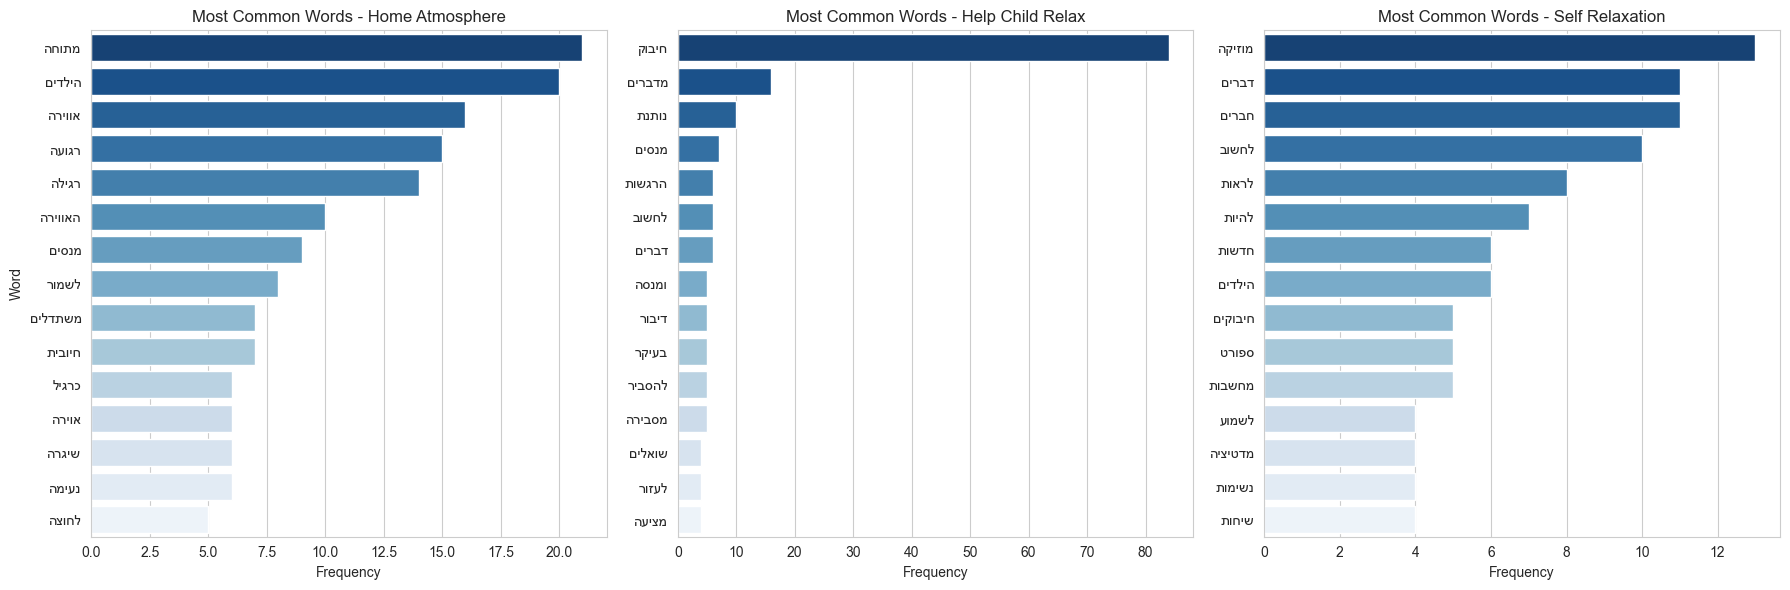

In [51]:
def extract_clean_words(series, normalize_map=None, excluded_words=None):
    if normalize_map is None:
        normalize_map = {}
    if excluded_words is None:
        excluded_words = []
    all_words = []
    for sentence in series.dropna().astype(str):
        for word in sentence.split():
            word = normalize_map.get(word, word)
            if len(word) > 4 and word not in excluded_words:
                all_words.append(word)

    return all_words

normalize_map = {
    "חיבוק": "חיבוק",
    "חיבוק,": "חיבוק",
    "מחבקת": "חיבוק",
    "לחבק": "חיבוק",
    "מחבקים": "חיבוק",
    "חברים,": "חברים",
    "מדיטציה,": "מדטיציה",
}

columns = [
    ("home_atmosphere", "Home Atmosphere"),
    ("help_child_relax", "Help Child Relax"),
    ("self_relax_strategies", "Self Relaxation")
]

sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

#גרף ראשון
words1 = extract_clean_words(df["home_atmosphere"], normalize_map)
word_freq1 = Counter(words1).most_common(15)
word_df1 = pd.DataFrame(word_freq1, columns=["Word", "Frequency"])
word_df1["Word"] = word_df1["Word"].apply(reshape_text)

sns.barplot(y=word_df1["Word"], x=word_df1["Frequency"], hue=word_df1["Word"],palette="Blues_r", ax=axes[0], legend=False)
axes[0].set_title("Most Common Words - Home Atmosphere", fontsize=12)
axes[0].set_xlabel("Frequency")
axes[0].set_ylabel("Word")

#גרף 2
words2 = extract_clean_words(df["help_child_relax"], normalize_map)
word_freq2 = Counter(words2).most_common(15)
word_df2 = pd.DataFrame(word_freq2, columns=["Word", "Frequency"])
word_df2["Word"] = word_df2["Word"].apply(reshape_text)

sns.barplot(y=word_df2["Word"], x=word_df2["Frequency"], hue=word_df2["Word"],palette="Blues_r", ax=axes[1], legend=False)
axes[1].set_title("Most Common Words - Help Child Relax", fontsize=12)
axes[1].set_xlabel("Frequency")
axes[1].set_ylabel("")

#גרף שלישי
words3 = extract_clean_words(df["self_relax_strategies"], normalize_map)
word_freq3 = Counter(words3).most_common(15)
word_df3 = pd.DataFrame(word_freq3, columns=["Word", "Frequency"])
word_df3["Word"] = word_df3["Word"].apply(reshape_text)

sns.barplot(y=word_df3["Word"], x=word_df3["Frequency"], hue=word_df3["Word"],palette="Blues_r", ax=axes[2], legend=False)
axes[2].set_title("Most Common Words - Self Relaxation", fontsize=12)
axes[2].set_xlabel("Frequency")
axes[2].set_ylabel("")
plt.tight_layout()
plt.show()



### 👥📊Participant Profile and Demographic Overview
<div dir='rtl'>
חלק זה נעשה על מנת לנסות להכיר את האוכלוסייה עליהם בוצע המחקר בצורה מעמיקה יותר וכך גם לדעת לאיזה סוג שאלות עלינו לכוון במהלך העבודה.
</div>

<div dir='rtl'>
  <strong style="font-size: 18px;">סטטיסטיקות עבור נתוני רקע:</strong>
</div>
<div dir='rtl'>
    הטבלה הבאה מציגה מדדים סטטיסטיים תיאורטיים עבור מספר משתני רקע מרכזיים:
  <br>
    גיל הילד, גיל ההורים, אחוזי משרה בזמן השגרה והמלחמה, ושינויים בשעות התעסוקה בעקבות פרוץ הלחימה.
  <br>
    מטרת הצגה זו היא לספק תמונה כללית על מאפייני אוכלוסיית המדגם.
</div>


In [52]:
dic_df=df[["age_child","parent_age","second_parent_age","parent_job_pct_current_num","second_parent_job_pct_war_num","job_change_parent","job_change_second_parent"]] #ראינו כי ישנו ילד בנתונים אשר הוריו טעו וכתבו שם ככה"נ את תאריך לידתם ועל כן סיננו עד גיל מסויים
filterd_dic=dic_df[dic_df["age_child"]<18]
filterd_dic.describe().style.background_gradient()

,age_child,parent_age,second_parent_age,parent_job_pct_current_num,second_parent_job_pct_war_num,job_change_parent,job_change_second_parent
count,165.000000,165.000000,160.000000,165.000000,157.000000,165.000000,157.000000
mean,6.824242,37.900000,39.250000,77.503030,79.458599,-12.800000,-22.292994
std,2.059930,5.951839,6.194946,41.897468,42.033944,32.606336,45.076468
min,1.000000,24.000000,26.000000,0.000000,0.000000,-150.000000,-150.000000
25%,6.000000,33.000000,35.000000,50.000000,50.000000,-25.000000,-50.000000
50%,7.000000,38.000000,39.500000,100.000000,100.000000,0.000000,0.000000
75%,8.000000,43.000000,44.000000,100.000000,100.000000,0.000000,0.000000
max,15.000000,50.000000,53.000000,150.000000,150.000000,75.000000,100.000000


<div dir='rtl'>
  <strong style="font-size: 18px;">פילוח קבוצות גילאים ע"פ מגדר:</strong>
</div>
<div dir='rtl'>
     הגרפים הבאים מציגים את פילוח קבוצות הגילאים של אוכלוסיית המדגם, תוך חלוקה לפי מגדר ההורה או הילד.
</div>


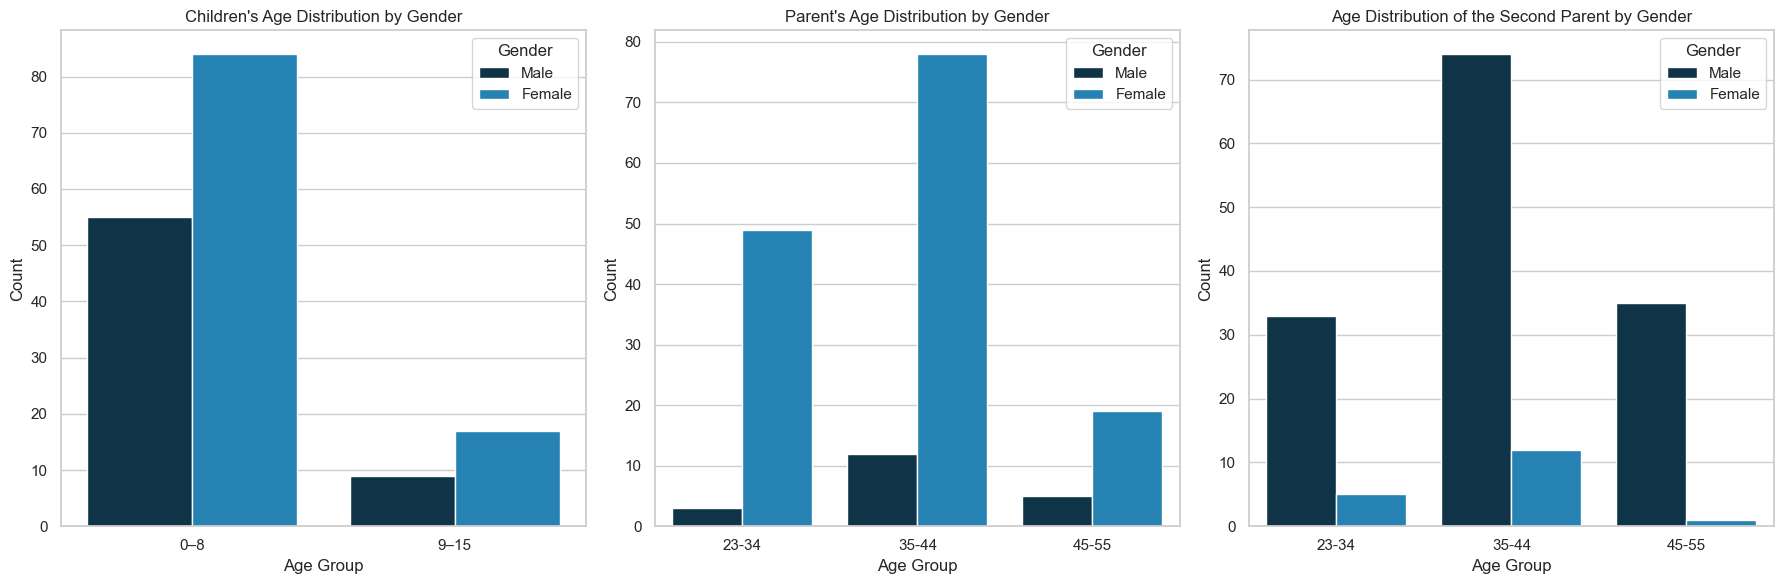

In [53]:
sns.set(style="whitegrid")
colors = ["#063751", "#0E89CB"]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.countplot(data=df, x="age_group_child", hue="Gender",hue_order=["Male", "Female"], palette=colors, ax=axes[0])
axes[0].set_title("Children's Age Distribution by Gender")
axes[0].set_xlabel("Age Group")
axes[0].set_ylabel("Count")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["0–8", "9–15"])
axes[0].legend(title="Gender")

sns.countplot(data=df, x="parent_age_group", hue="Gender_parent_TXT", hue_order=["Male", "Female"], palette=colors, ax=axes[1])
axes[1].set_title("Parent's Age Distribution by Gender")
axes[1].set_xlabel("Age Group")
axes[1].set_ylabel("Count")
axes[1].set_xticks([0, 1, 2])
axes[1].set_xticklabels(["23-34", "35-44", "45-55"])
axes[1].legend(title="Gender")


sns.countplot(data=df, x="second_parent_age_group", hue="second_parent_gender_TXT",hue_order=["Male", "Female"], palette=colors, ax=axes[2])
axes[2].set_title("Age Distribution of the Second Parent by Gender")
axes[2].set_xlabel("Age Group")
axes[2].set_ylabel("Count")
axes[2].set_xticks([0, 1, 2])
axes[2].set_xticklabels(["23-34", "35-44", "45-55"])
axes[2].legend(title="Gender")


plt.tight_layout()
plt.show()

<div dir='rtl'>
ניתן לראות כי רובו המוחלט של ממלאי השאלון הינן אמהות.
</div>

<div dir='rtl'>
  <strong style="font-size: 18px;">התפלגות לפי מצב מגורים נוכחי של המשפחה:</strong>
</div>
<div dir='rtl'>
    התרשים מציג את פילוג המשתתפים בהתאם למצב המגורים הנוכחי שלהם על מנת להציג את נתח אוכלוסיית המדגם שפונו מבתיהם.   
  </p>
</div>


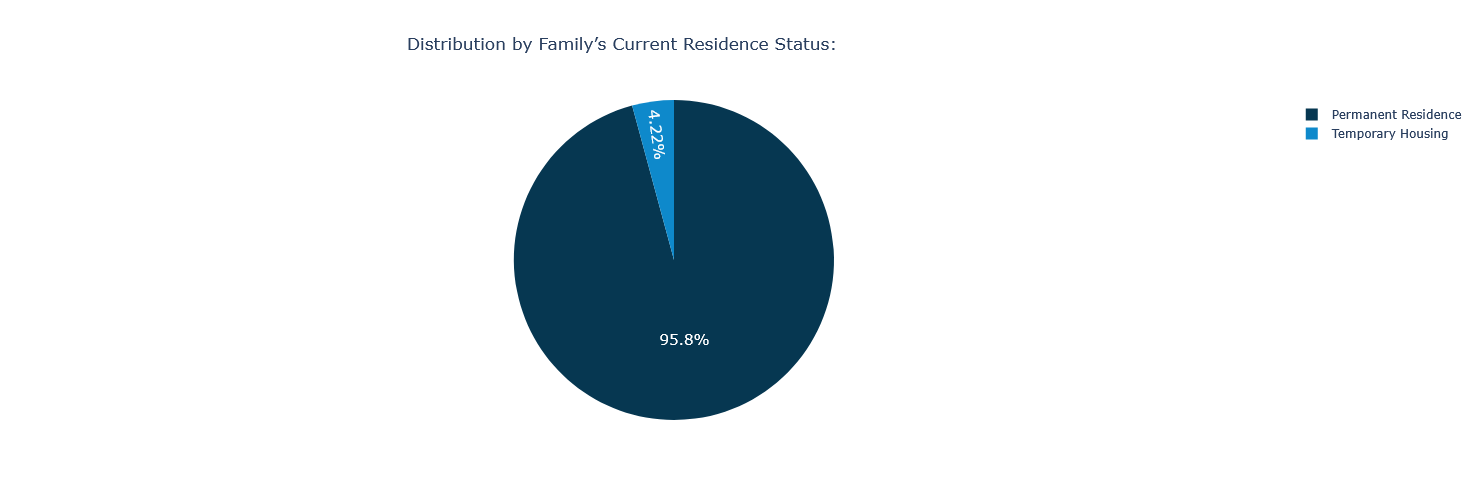

In [54]:
res_counts = df["Family’s Current Residence"].value_counts() 
fig = go.Figure(data=[go.Pie(labels= res_counts.index, marker_colors=['063751', '0E89CB'], values=res_counts.values, textfont_size=15)])
fig.update_layout(width=700, height=500, title='Distribution by Family’s Current Residence Status:', title_x=0.42)
fig.show()

<div dir='rtl'>
ע"פ המוצג בגרף, ניתן לראות כי רובן המוחלט של המשפחות אשר ענו על הסקר לא פונו מבתיהם.
</div>

<div dir='rtl'>
  <strong style="font-size: 18px;">סטטוס גיוס במשפחה:</strong>
</div>
<div dir='rtl'>
    התרשים מדגים את התפלגות המשתתפים בהתאם לשאלה האם אחד מבני המשפחה גויס לשירות מילואים או צבאי בעקבות המלחמה.
</div>


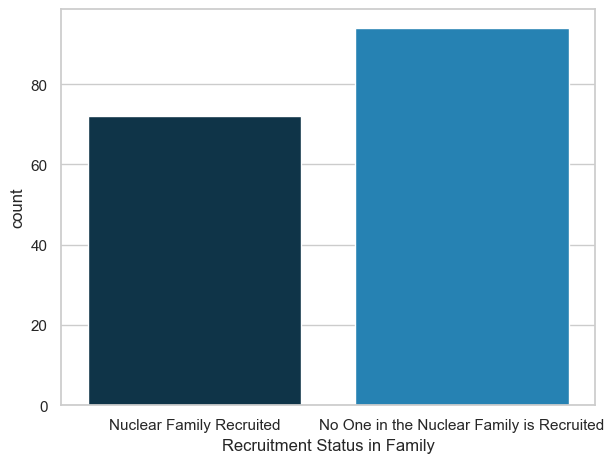

In [55]:
sns.set(style="whitegrid")
colors = ["#063751", "#0E89CB"]
sns.countplot(data=df, x='Recruitment Status in Family',hue='Recruitment Status in Family',palette=colors, legend=False)
plt.xlabel('Recruitment Status in Family')
plt.ylabel('count')
plt.tight_layout()
plt.show()


<div dir='rtl'>
  <strong style="font-size: 18px;">נפגעים במעגל הקרוב:</strong>
</div>
<div dir='rtl'>
    בתרשים זה נבחנת השאלה האם למשתתפים היו קרובים שנפגעו במהלך המלחמה (הרוגים/פצועים/חטופים).
<br>
    משתנה זה חיוני להבנת גודל החשיפה האישית לאירועי טראומה, והשפעתה על תגובות רגשיות והתנהגותיות.
  </p>
</div>


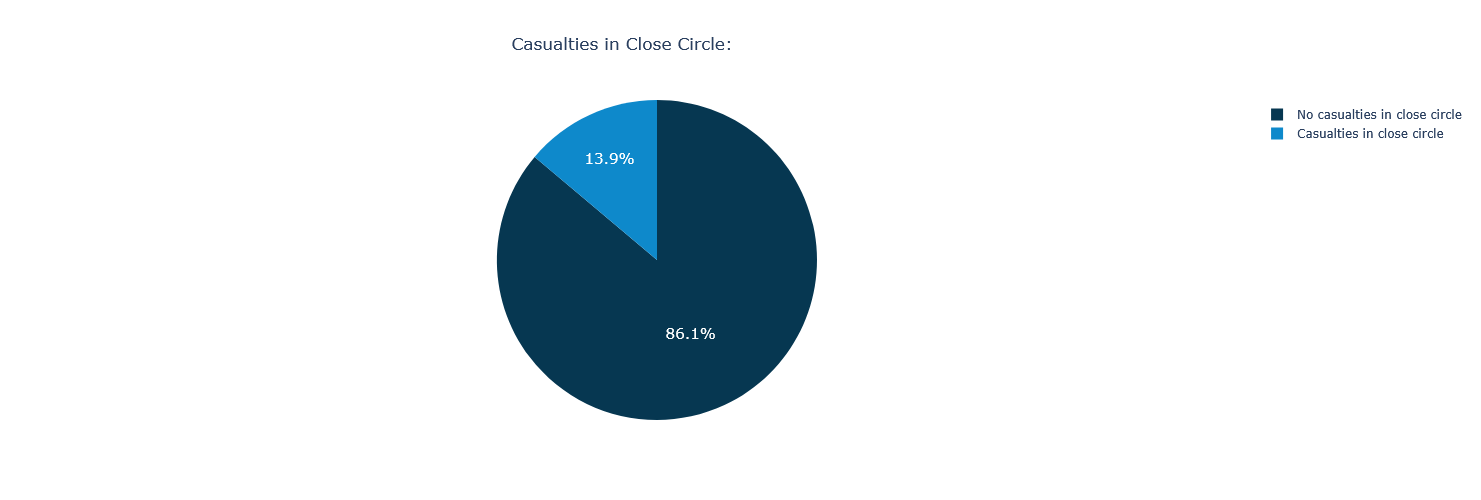

In [56]:
label_map = {1: "No casualties in close circle", 2: "Casualties in close circle"}
df["casualties_label"] = df["casualties_close"].map(label_map)
num_counts = df["casualties_label"].value_counts() 
fig = go.Figure(data=[go.Pie(labels= num_counts.index, marker_colors=['063751', '0E89CB'], values=num_counts.values, textfont_size=15)])
fig.update_layout(width=700, height=500, title='Casualties in Close Circle:', title_x=0.42)
fig.show()

<h2 style="color: #345682">🔍 Correlation Analysis</h2>

#### 🧮 Preparing Data for Correlation

In [57]:
df["the_place_in_fam_encoded"]=pd.Categorical(df["the_place_in_fam"]).codes
df["age_group_child_encoded"]=pd.Categorical(df["age_group_child"]).codes
df["parent_age_group_encoded"]=pd.Categorical(df["parent_age_group"] ).codes
df["second_parent_age_group_encoded"]=pd.Categorical(df["second_parent_age_group"]).codes

In [58]:
df["Gender_child_encoded"] = df["Gender"].map({"Male": 1, "Female": 2})
df['Family’s Current Residence_encoded'] = df["Family’s Current Residence"].map({"Permanent Residence": 0,"Temporary Housing": 1})

In [59]:
religiosity_order = [
    'חילוני',
    'חילוני, מסורתי',
    'מסורתי',
    'מסורתי, דתי',
    'דתי',
    'דתי, חרדי',
    'חרדי'
]
df["religiosity_encoded"] = pd.Categorical(df["religiosity"], categories=religiosity_order, ordered=True).codes

In [60]:
education_levels2 = {
    "בית ספר תיכון": 1,
    "תעודה על תיכונית": 2,
    "השכלה מקצועית": 2,
    "הכשרה מקצועית": 2,
    "תואר ראשון": 3,
    "תואר שני": 4,
    "תואר שלישי": 5,
    "תעודה על תיכונית, הכשרה מקצועית, תואר ראשון": 3,
    "תעודה על תיכונית, הכשרה מקצועית": 2,
    "הכשרה מקצועית, תואר ראשון": 3,
    "תואר ראשון, תואר שני": 4,
    "בית ספר תיכון, תעודה על תיכונית, הכשרה מקצועית": 2
}
df["parent_education_encoded"] = df["parent_education"].replace(education_levels2).astype("Int64")

C:\Users\lihin\AppData\Local\Temp\ipykernel_74816\2120198843.py:15: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



In [61]:
education_levels1 = {
    "בית ספר תיכון": 1,
    "תעודה על תיכונית": 2,
    "השכלה מקצועית": 2,
    "הכשרה מקצועית": 2,
    "תואר ראשון": 3,
    "תואר שני": 4,
    "תואר שלישי": 5,
    "תעודה על תיכונית, תואר ראשון": 3,
    "בית ספר תיכון, הכשרה מקצועית": 2,
    "תעודה על תיכונית, הכשרה מקצועית": 2,
    "תואר שני, תואר שלישי": 5,
    "הכשרה מקצועית, תואר ראשון": 3,
    "תואר ראשון, תואר שני": 4,
    "בית ספר תיכון, תעודה על תיכונית, הכשרה מקצועית": 2
}
df["second_parent_education_encoded"] = df["second_parent_education"].replace(education_levels1).astype("Int64")

C:\Users\lihin\AppData\Local\Temp\ipykernel_74816\1203036477.py:17: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



#### 🔗 Correlation:

<div dir='rtl'>
בשלב זה של העבודה, בוצע ניתוח קורלציה בין כלל המשתנים הכמותיים שנאספו או גובשו במהלך תהליך העיבוד, לרבות ממוצעים קבוצתיים שגובשו עבור רגשות ההורים והילדים,.
<br>
המטרה הייתה לחפש קשרים מובהקים בין משתנים, על מנת לחפש כיווני ניתוח מעמיקים יותר בהמשך.
</div>

In [62]:
child_related = ['num_children','Gender_child_encoded','age_group_child_encoded','child_empathy','child emotion regulation-positive','child emotion regulation-negative','easy_regulate_positive','easy_regulate_negative','easy_sleep','nightmares','alarm_fear_child',"the_place_in_fam_encoded",'inc_neg_emotions',"num_rooms"]
parent_family_related = ['parent_age_group_encoded','second_parent_age_group_encoded','parent_aliyah_year','second_parent_aliyah_year','Gender_parent_encoded','second_parent_gender_encoded','parent_job_pct_current_num','second_parent_job_pct_war_num','job_change_parent','job_change_second_parent','parent emotion regulation-reappraisel','parent emotion regulation-suppression','parents emotional expersivness-positive','parents emotional expersivness-negative','casualties_close','news_exposure_binary','Recruitment_Status_binary','Family’s Current Residence_encoded','religiosity_encoded','parent_education_encoded','second_parent_education_encoded']
cor_df=df[child_related+parent_family_related]

In [63]:
correlation_matrix = cor_df.corr(numeric_only = True).round(2)
correlation_matrix

,num_children,Gender_child_encoded,age_group_child_encoded,child_empathy,child emotion regulation-positive,child emotion regulation-negative,easy_regulate_positive,easy_regulate_negative,easy_sleep,nightmares,...,parent emotion regulation-suppression,parents emotional expersivness-positive,parents emotional expersivness-negative,casualties_close,news_exposure_binary,Recruitment_Status_binary,Family’s Current Residence_encoded,religiosity_encoded,parent_education_encoded,second_parent_education_encoded
num_children,1.00,0.09,0.11,-0.01,-0.08,-0.06,0.15,0.10,0.06,0.03,...,-0.10,0.01,0.15,0.14,0.11,0.06,-0.14,0.35,0.06,0.09
Gender_child_encoded,0.09,1.00,0.02,0.13,0.16,-0.07,0.12,0.19,0.05,-0.03,...,0.03,-0.09,-0.12,0.07,0.04,0.02,-0.02,0.06,-0.12,0.06
age_group_child_encoded,0.11,0.02,1.00,0.00,-0.18,-0.02,-0.08,-0.03,0.01,0.07,...,0.03,-0.04,0.15,-0.02,-0.14,0.07,-0.00,-0.03,0.05,0.10
child_empathy,-0.01,0.13,0.00,1.00,0.13,-0.18,0.13,0.20,-0.05,0.20,...,-0.08,0.47,0.07,0.04,0.07,0.01,-0.17,-0.04,0.04,0.02
child emotion regulation-positive,-0.08,0.16,-0.18,0.13,1.00,0.17,-0.00,-0.04,0.04,-0.02,...,0.02,-0.07,-0.20,0.06,-0.13,0.06,0.04,0.24,-0.23,-0.12
child emotion regulation-negative,-0.06,-0.07,-0.02,-0.18,0.17,1.00,-0.22,-0.32,-0.29,0.11,...,-0.09,-0.30,0.16,-0.11,0.00,-0.07,0.21,0.09,-0.13,-0.03
easy_regulate_positive,0.15,0.12,-0.08,0.13,-0.00,-0.22,1.00,0.34,0.28,0.03,...,-0.03,0.24,0.01,0.01,0.02,0.05,-0.01,0.04,0.08,0.00
easy_regulate_negative,0.10,0.19,-0.03,0.20,-0.04,-0.32,0.34,1.00,0.47,-0.11,...,-0.08,0.30,-0.17,0.05,0.02,-0.03,-0.05,0.03,0.08,0.07
easy_sleep,0.06,0.05,0.01,-0.05,0.04,-0.29,0.28,0.47,1.00,-0.28,...,-0.02,0.09,-0.18,-0.04,-0.11,0.02,-0.06,-0.01,0.05,0.07
nightmares,0.03,-0.03,0.07,0.20,-0.02,0.11,0.03,-0.11,-0.28,1.00,...,0.05,-0.03,0.10,0.02,0.05,-0.16,0.12,0.06,-0.03,-0.07


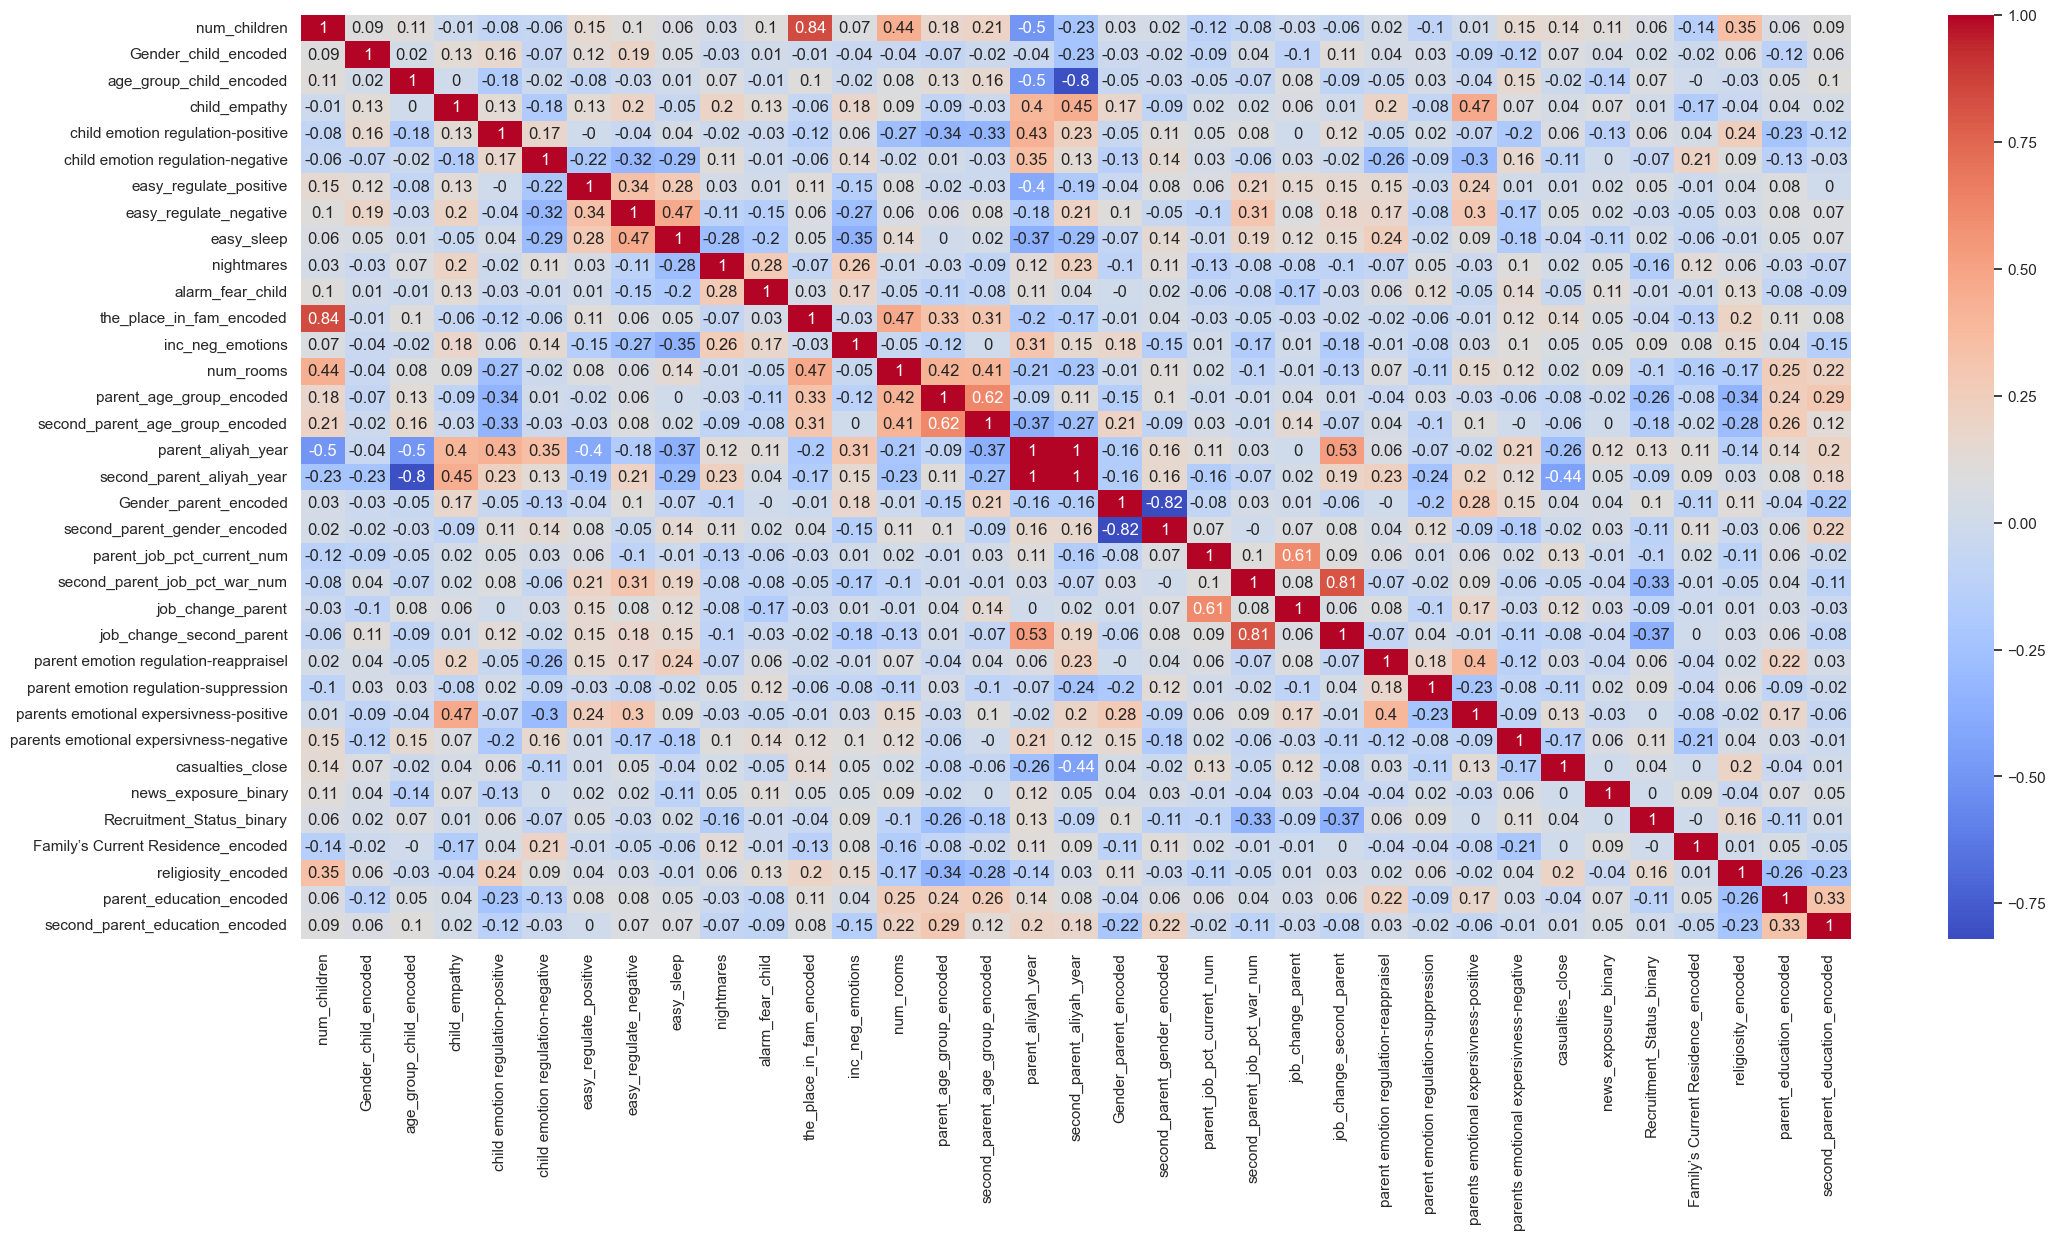

In [64]:
plt.figure(figsize=(25,12))
sns.heatmap(data=correlation_matrix,cmap='coolwarm', annot=True)
plt.show()

<h2 style="color: #345682">📈📘 Emotional Impact of Parental Soothing on Children</h2>

<div dir='rtl'>
  מטרת חלק זה היא לבחון כיצד אסטרטגיות הרגעה שונות בהן נעזרו הורים במהלך תקופת המלחמה משפיעות על היבטים רגשיים והתנהגותיים של ילדיהם.
  <br>
  ניתוח זה מתמקד בשלושה נקודות עיקריות:
  <ul>
    <li>זיהוי שיטות ההרגעה הנפוצות ביותר שנקטו הורים להרגעת ילדיהם.</li>
    <li>
      בחינת ההשפעה של שיטות שונות על המצב הרגשי של הילדים:
      <ul style="list-style-type: circle; padding-right: 20px;">
        <li>כולל התמקדות בשיטות "עצמאי/עקיף" כגון זמן לבד, והסחת דעת.</li>
      </ul>
    </li>
    <li>השוואת יעילות שיטות ההרגעה על מהירות ההירדמות של ילדים, תוך הבחנה בין ילדים שחוו רגרסיה לבין אלו שלא.</li>
  </ul>
</div>


<div dir='rtl'>
  <strong style="font-size: 18px;">ניתוח מילולי של תגובות ההורים – כיצד ניסו להרגיע את ילדיהם?</strong>
</div>

<div dir='rtl'>
כחלק מהבנת הדרכים בהן הורים ניסו לסייע לילדיהם להירגע במהלך תקופת המלחמה, נותחו תשובות פתוחות שניתנו בשאלה חופשית. ניתוח זה התבצע באמצעות יצירת "ענן מילים" – כלי חזותי המאפשר לזהות אילו ביטויים, מילים או מושגים חזרו על עצמם בתדירות גבוהה.
<br>
לפני יצירת הענן בוצע תהליך של ניקוי ואיחוד מילים (למשל, המילים "לחבק", "חיבוקים" ו"מחבקת" אוחדו ל"חיבוק"), במטרה לשקף טוב יותר את הכוונה המקורית של ההורים ולמנוע פיזור מיותר בין וריאציות לשוניות. גודל המילים בענן מייצג את שכיחות הופעתן בדיווחי ההורים.
</div>


In [67]:
normalize_map = {
    "חיבוקים": "חיבוק",
    "חיבוק,": "חיבוק",
    "מחבקת": "חיבוק",
    "לחבק": "חיבוק",
    "מחבקים": "חיבוק",
    "מתחבקים": "חיבוק",}

all_words = []
for sentence in df["help_child_relax"].dropna().astype(str):
    for word in sentence.split():
        word = word.strip(".,!?\"'")  
        word = normalize_map.get(word, word)  
        if len(word) > 3:
            word = reshape_text(word)
            all_words.append(word)

text = " ".join(all_words)
word_counts = Counter(all_words)
most_common_word = word_counts.most_common(1)[0][0]

def blue_shades_color_func(word, font_size, position, orientation, font_path, random_state):
    if word == most_common_word:
        return "#003366"
    else:
        return "#6699CC"

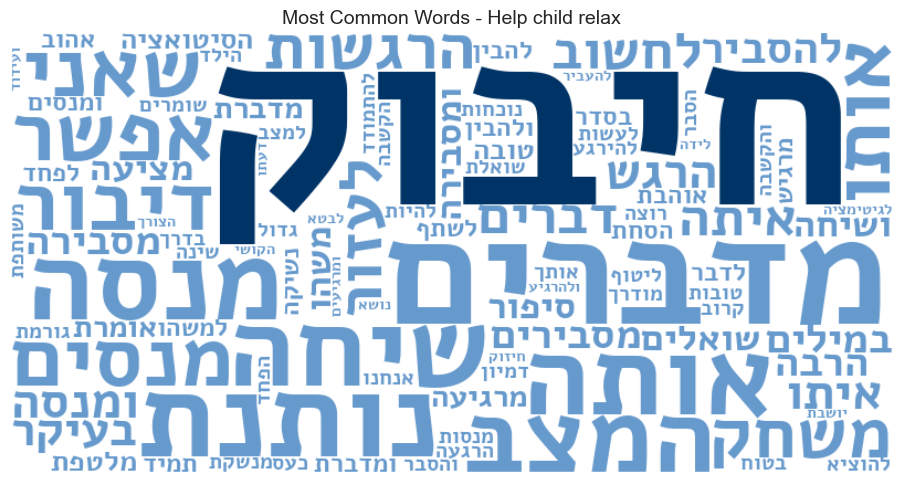

In [71]:


wordcloud = WordCloud(font_path="Alef-Bold.ttf",width=800,height=400,background_color="white",colormap="Blues",max_words=100,relative_scaling=0.5).generate(text)

plt.figure(figsize=(12, 5))
plt.imshow(wordcloud.recolor(color_func=blue_shades_color_func), interpolation="bilinear")
plt.axis("off")
plt.title("Most Common Words - Help child relax", fontsize=14)
plt.tight_layout()
plt.show()


<div dir='rtl'>
ניתן לראות כי המילה הבולטת ביותר שהתגלתה היא <b>חיבוק</b>.
<br>
<div dir='rtl'>
לאחר שזיהינו את המילה הנפוצה ביותר בעמודת השאלה הפתוחה, בחנו את השפעתן על שני מדדים מרכזיים ברווחה הרגשית של הילד לאחר המלחמה: היכולת לווסת רגשות שליליים ורמת האמפתיה שגילה כלפי אחרים.
</div>


<div dir='rtl'>
  <strong style="font-size: 18px;">כיצד שיטות הרגעה שונות משפיעות על המצב הרגשי של ילדים?</strong>
</div>

<div dir='rtl'>
במטרה להבין כיצד שיטות הרגעה שונות שננקטו על ידי ההורים השפיעו על הרווחה הרגשית של ילדיהם לאחר המלחמה, נבחנו שני מדדים מרכזיים: וויסות רגשות שלילי ואמפתיה של הילד.
<br>
הגרף שלפניכם מציג את הממוצעים של שני המדדים עבור כל אחת משיטות ההרגעה, כפי שדווחו על ידי ההורים. מטרת ההשוואה היא לזהות אילו שיטות תרמו ליכולת טובה יותר של הילד לווסת רגשות שליליים ולגלות אמפתיה.
</div>


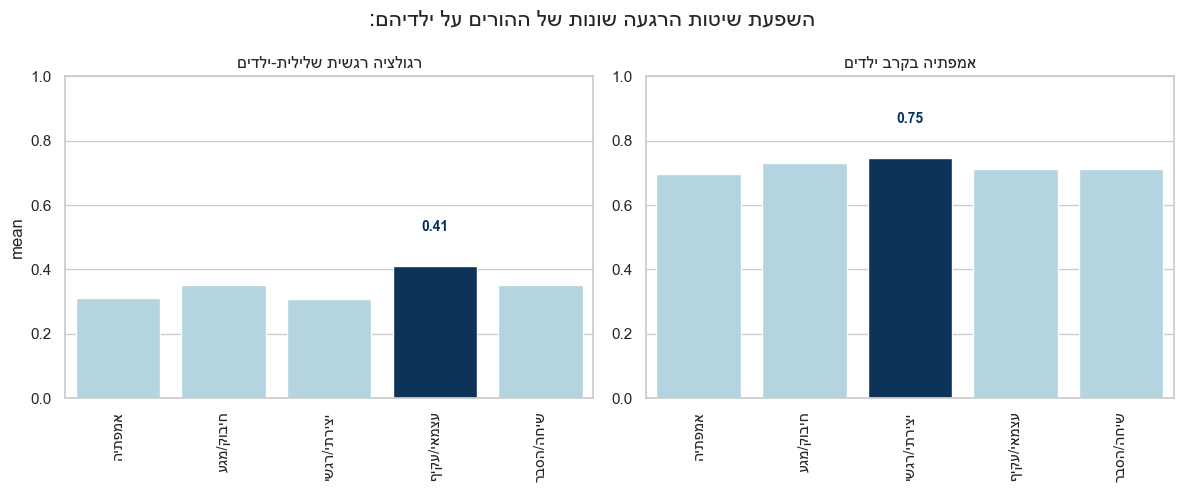

In [72]:
max_semicomma = df.dominant_method.str.count(',').max()
split_df = df["dominant_method"].str.split(",", n=max_semicomma, expand=True)
target = ["child emotion regulation-negative", "child_empathy"]
new_df = pd.concat([df[target], split_df], axis=1)

method_cols = [0, 1, 2, 3]
long_df = new_df.melt(id_vars=target, value_vars=method_cols, value_name="method").copy()
long_df = long_df.dropna(subset=["method"]) 
long_df = long_df[(long_df["method"] != "לא זוהה")]

groupby = long_df.groupby('method')[target].mean().reset_index()

groupby["method_reshaped"] = groupby["method"].apply(reshape_text)

def annotate_max_bar(ax, x_pos, y_val):ax.text(x=x_pos,y=y_val + 0.1,s=f"{y_val:.2f}",ha='center',va='bottom',fontsize=10,fontweight='bold',color='#003366')
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

values_neg = groupby["child emotion regulation-negative"].values
max_idx_neg = np.argmax(values_neg)
palette_neg = ["lightblue"] * len(values_neg)
palette_neg[max_idx_neg] = "#003366"

sns.barplot(data=groupby,x="method_reshaped",y="child emotion regulation-negative",hue="method_reshaped", ax=axes[0],palette=palette_neg,legend=False,errorbar=None)
annotate_max_bar(axes[0], max_idx_neg, values_neg[max_idx_neg])
axes[0].set_title(reshape_text("רגולציה רגשית שלילית-ילדים"), fontsize=12)
axes[0].tick_params(axis="x", rotation=90)
axes[0].set_ylim(0, 1)
axes[0].set_xlabel("")
axes[0].set_ylabel("mean")

values_pos = groupby["child_empathy"].values
max_idx_pos = np.argmax(values_pos)
palette_pos = ["lightblue"] * len(values_pos)
palette_pos[max_idx_pos] = "#003366"

sns.barplot(data=groupby,x="method_reshaped",y="child_empathy",hue="method_reshaped", ax=axes[1],palette=palette_pos,legend=False,errorbar=None)
annotate_max_bar(axes[1], max_idx_pos, values_pos[max_idx_pos])
axes[1].set_title(reshape_text("אמפתיה בקרב ילדים"), fontsize=12)
axes[1].tick_params(axis="x", rotation=90)
axes[1].set_ylim(0, 1)
axes[1].set_xlabel("")
axes[1].set_ylabel("")

plt.suptitle(reshape_text("השפעת שיטות הרגעה שונות של ההורים על ילדיהם:"), fontsize=16)
plt.tight_layout()
plt.show()


<div dir='rtl'>
מהנתונים עולה כי ילדים שהוריהם בחרו בשיטות הרגעה יצירתיות או כאלה שפועלות על הרגש הפגינו על פי דיווחי ההורים אמפטיה גבוהה יותר.
<br>
מנגד, ילדים שהוריהם השתמשו בשיטות הרגעה עצמאיות או עקיפות (זמן לבד או הסחת דעת) מדורגים על ידי הוריהם גם כילדים אשר מביעים וויסות רגשות שליליים באופן גבוה יותר.
</div>

<div dir='rtl'>
לאור הממצאים הקודמים אשר הצביעו על הקשר בין שיטת ההרגעה "עצמאי/עקיף" לבין קשיים בוויסות רגשות שלילים, ביצענו ניתוח נוסף המתמקד בילדים שהוריהם דיווחו על שימוש בשיטה זו.
<br>
מטרת ניתוח זה הייתה לחזק את ההבנה בנוגע להשפעות שונוות של שימוש  בשיטות התמודדות עצמאי/עקיף (זמן לבד או הסחת דעת) במהלך תקופת המלחמה.
</div>


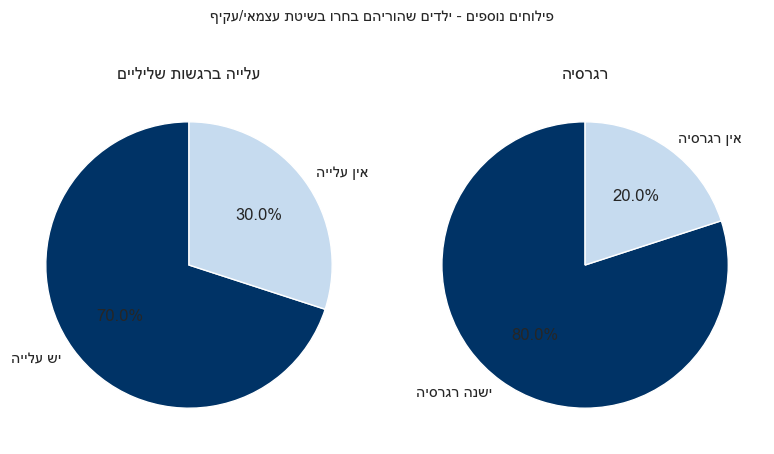

In [73]:
alone_df = df[df["dominant_method"].str.contains("עצמאי/עקיף", na=False)].copy()
inc_neg_counts = alone_df["inc_neg_emotions_binary"].value_counts()
regression_counts = alone_df["regression_cat"].value_counts()

labels_inc = [reshape_text("יש עלייה"), reshape_text("אין עלייה")]
labels_reg = [reshape_text("ישנה רגרסיה"), reshape_text("אין רגרסיה")]

colors = ['#003366', '#c6dbef']
fig, axes = plt.subplots(1, 2, figsize=(8, 5))
axes[0].pie(inc_neg_counts, labels=labels_inc, autopct='%1.1f%%', colors=colors, startangle=90)
axes[0].set_title(reshape_text("עלייה ברגשות שליליים"))

axes[1].pie(regression_counts, labels=labels_reg, autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title(reshape_text("רגרסיה"))

plt.suptitle(reshape_text("פילוחים נוספים - ילדים שהוריהם בחרו בשיטת עצמאי/עקיף"), fontsize=11)
plt.tight_layout()
plt.show()


<div dir='rtl'>
ניתן לראות כי מתוך כלל ההורים שבחרו בשיטת "עצמאי/עקיף",  80% היו הורים לילדים עם רגרסיה ו־70% דיווחו על עלייה ברגשות שליליים
</div>

<div dir='rtl'>
<strong style="font-size: 18px;">שיטות הרגעה והשפעתן על מהירות ההירדמות – בקרב ילדים עם וללא רגרסיה</strong>
</div>
<div dir='rtl'>
במטרה להבין כיצד שיטות הרגעה שונות השפיעו על מהירות ההירדמות של ילדים לאחר המלחמה, בדקנו את תשובת ההורים בנוגע למהירות הירדמות ילדיהם, תוך הבחנה בין ילדים שחוו רגרסיה לבין אלו שלא.
</div>

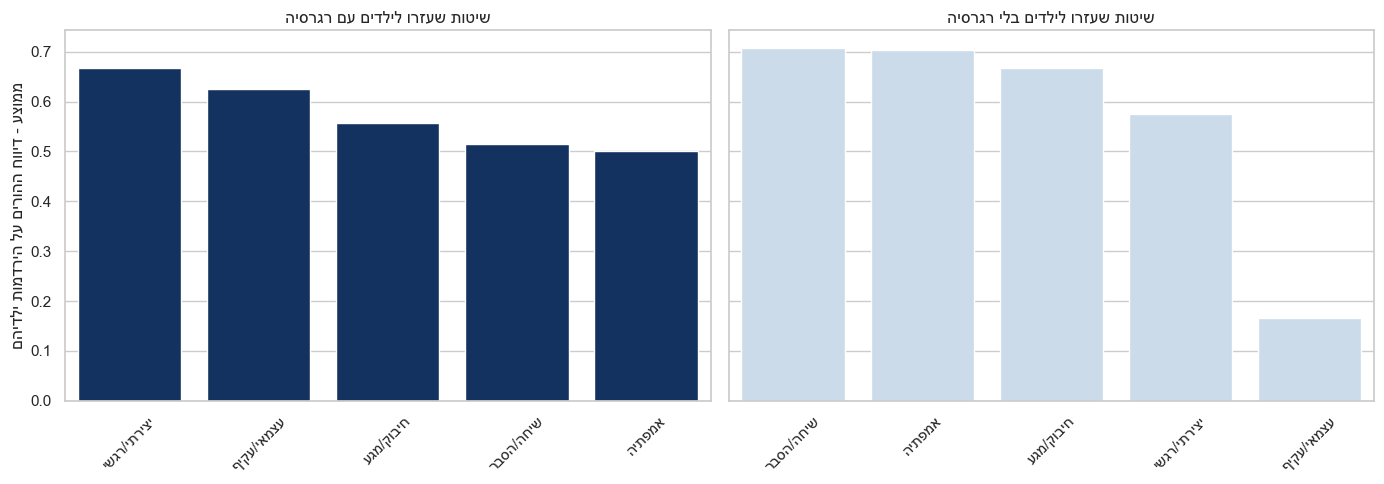

In [74]:
max_semicomma = df.dominant_method.str.count(',').max()
split_df = df["dominant_method"].str.split(",", n=max_semicomma, expand=True)

target = ["easy_sleep", "regression_cat"]
new_df = pd.concat([df[target], split_df], axis=1)

method_cols = split_df.columns.tolist()
long_df = new_df.melt(id_vars=target, value_vars=method_cols, value_name="method")
long_df = long_df.dropna(subset=["method"])
long_df = long_df[~long_df["method"].str.strip().isin(["לא זוהה", "שיר", "סיפור", "משחק"])]

grouped = long_df.groupby(["method", "regression_cat"])["easy_sleep"].mean().reset_index()
grouped["method_reshaped"] = grouped["method"].apply(reshape_text)

with_regression = grouped[grouped["regression_cat"] == "כן"].sort_values("easy_sleep", ascending=False)
without_regression = grouped[grouped["regression_cat"] == "לא"].sort_values("easy_sleep", ascending=False)

with_regression["method_reshaped"] = with_regression["method"].apply(reshape_text)
without_regression["method_reshaped"] = without_regression["method"].apply(reshape_text)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

sns.barplot(data=with_regression, x="method_reshaped", y="easy_sleep", ax=axes[0], color="#08306b")
axes[0].set_title(reshape_text("שיטות שעזרו לילדים עם רגרסיה"))
axes[0].set_xlabel("")
axes[0].set_ylabel(reshape_text("ממוצע - דיווח ההורים על הירדמות ילדיהם"))
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=without_regression, x="method_reshaped", y="easy_sleep", ax=axes[1], color="#c6dbef")
axes[1].set_title(reshape_text("שיטות שעזרו לילדים בלי רגרסיה"))
axes[1].set_xlabel("")
axes[1].set_ylabel("")  
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


<div dir="rtl">
    שילוב שלושת הגרפים מצביע על התמונה הבאה: ע"פ הגרף השני הורים שבחרו בשיטות הרגעה מסוג "עצמאי/עקיף" נטו להיות הורים לילדים שחוו רגרסיה ועלייה ברגשות שליליים.
    <br>
    עם זאת, דווקא בקבוצת ילדים זו (עם רגרסיה), שיטות כמו "יצירתי/רגשי" ו־"עצמאי/עקיף" נקשרו להירדמות קלה יותר.
    <br>
    מנגד, בקרב ילדים שלא חוו רגרסיה, שיטות מבוססות קרבה כמו "חיבוק", "שיחה/הסבר" ו"אמפתיה" נמצאו כיעילות יותר לקידום הירדמות.
    <br>
    ממצאים אלו מדגישים כי אין שיטת הרגעה אחת שמתאימה לכולם – שיטות עקיפות עשויות להועיל במצבי מצוקה, בעוד ששיטות ישירות מתאימות יותר כאשר הילד במצב רגשי יציב.
</div>


<h2 style="color: #345682">📊🧠 Emotional Effects of Parental Self-Calming Strategies</h2>

<div dir='rtl'>
  חלק זה עוסק בבחינת הקשר בין אסטרטגיות הרגעה עצמית שבחרו ההורים לבין מדדים רגשיים, הן ברמה האישית של ההורה והן ברמה הבין-אישית מול הילד:
</div>

<div dir='rtl'>
  <ul>
    <li>זיהוי השיטות הנפוצות ביותר להרגעה עצמית בקרב ההורים.</li>
    <li>בחינת השפעתן של שיטות הרגעה שונות על רמת ההבעה הרגשית החיובית של ההורה, תוך הבחנה לפי קרבה לנפגעים.</li>
    <li>
      השפעת חיבוק כשיטת ויסות רגשי – על הבעת רגשות חיוביים של ההורה ואמפתיה של הילד:
      <ul style="list-style-type: circle; padding-right: 20px;">
        <li>ע"פ חלוקה להורים אשר משתמשים בחיבוק כשיטת הרגעה עצמית והרגעת ילדיהם לעומת הורים שמשתמשים בחיבוק להרגעת ילדיהם בלבד./li>
      </ul>
    </li>
  </ul>
</div>


<div dir='rtl'>
  <strong style="font-size: 18px;">ניתוח מילולי של תגובות ההורים – כיצד ניסו להרגיע את עצמם?</strong>
</div>


<div dir='rtl'>
במטרה להבין כיצד הורים התמודדו בעצמם עם האתגר הרגשי בזמן הלחימה, ניתחנו את התשובות הפתוחות שסיפקו במסגרת השאלון. ענן המילים שלפניכם מציג את הביטויים הבולטים שחזרו על עצמם בתיאורי שיטות ההרגעה העצמית של ההורים.
<br>
לצורך ניתוח אחיד, מונחים דומים אוחדו לקטגוריות משותפות (לדוגמה: "שירים", "שרים", ו"מוזיקה" סווגו תחת "מוזיקה"). ככל שמילה מופיעה בגודל גדול יותר, הייתה שכיחה יותר בתשובות – ובכך היא מצביעה על אסטרטגיות ההרגעה המרכזיות שעמדו לרשות ההורים במהלך התקופה.
</div>


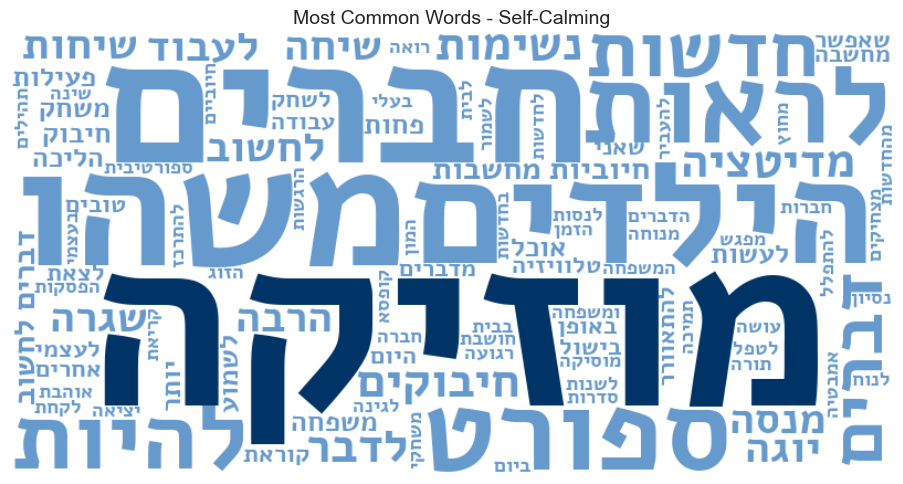

In [75]:
normalize_map = {
    "חיבוק": "חיבוק",
    "חיבוק,": "חיבוק",
    "מחבקת": "חיבוק",
    "לחבק": "חיבוק",
    "מחבקים": "חיבוק",
    "שיר": "מוזיקה",
    "שירים": "מוזיקה",
    "שרים": "מוזיקה",
    "לשיר": "מוזיקה",
    "מוזיקה": "מוזיקה",
    "מנגנים": "מוזיקה",
    "שומעים מוזיקה": "מוזיקה"
}

all_words = []

for sentence in df["self_relax_strategies"].dropna().astype(str):
    for word in sentence.split():
        word = word.strip(".,!?\"'") 
        word = normalize_map.get(word, word) 
        if len(word) > 3:
            word = reshape_text(word)  
            all_words.append(word)

text = " ".join(all_words)
word_counts = Counter(all_words)
most_common_word = word_counts.most_common(1)[0][0]
def blue_color(word, font_size, position, orientation, font_path, random_state): #חייבת את כל ה-4 ארגומנטים 
    if word == most_common_word:
        return "#003366"
    else:
        return "#6699CC"

wordcloud = WordCloud(font_path="Alef-Bold.ttf",width=800,height=400,background_color="white",colormap="Blues",max_words=100,relative_scaling=0.5).generate(text)

plt.figure(figsize=(12, 5))
plt.imshow(wordcloud.recolor(color_func=blue_color), interpolation="bilinear")
plt.axis("off")
plt.title("Most Common Words - Self-Calming", fontsize=14)
plt.tight_layout()
plt.show()

<div dir='rtl'>
ניתן לראות כי המילה הכי נפוצה הינה <b>מוזיקה</b>.
<br>
כעת, נרצה לבדוק מהי דרך ההרגעה שהשפיעה בצורה המירבית הן על ההורים ועל הילדים. 
</div>

<div dir='rtl'>
  <strong style="font-size: 18px;">השפעת שיטות הרגעה עצמאיות על הבעה רגשית חיובית של ההורים לפי קרבה לנפגעים</strong>
</div>

<div dir='rtl'>
מכיוון שנמצא כי הבעת רגשות חיוביים מצד ההורה קשורה לרמות האמפתיה של הילד, נבחנו כאן שיטות הרגעה עצמית שדווחו על ידי ההורים, כדי לזהות אילו מהן תורמות יותר לביטוי רגשות חיוביים – ובכך עשויות להשפיע גם בעקיפין על הילד. 
<br>
הגרפים מציגים שלוש קבוצות שיטות:
<ul>
  <li><strong>הורים עם קרובים שנפגעו:</strong> שיטות שהיו יעילות יותר להורים עם קרובים שנפגעו במהלך המלחמה</li>
  <li><strong>הורים ללא קרובים שנפגעו:</strong> שיטות שעזרו יותר ללא קרובים שנפגעו במהלך המלחמה</li>
  <li><strong>השפעה שווה:</strong> שיטות שהשפיעו באותה מידה על שתי הקבוצות.</li>
</ul>
</div>


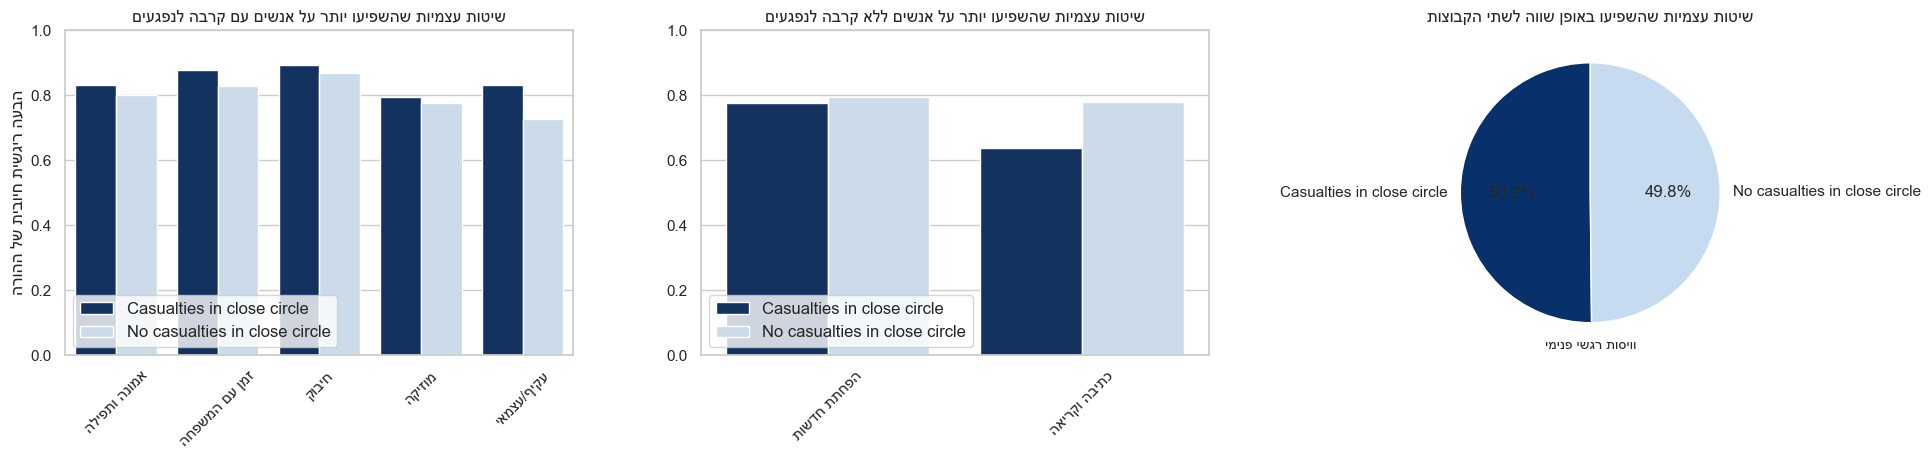

In [76]:
max_comma3 = df["dominant_method_self"].str.count(',').max()
split_df3 = df["dominant_method_self"].str.split(',', n=max_comma3, expand=True)

target = ["parents emotional expersivness-positive", "casualties_label"]
new_df3 = pd.concat([df[target], split_df3], axis=1)
method_cols = split_df3.columns.tolist()

long_df3 = new_df3.melt(id_vars=target, value_vars=method_cols, value_name="method").copy()
long_df3 = long_df3.dropna(subset=["method"])
long_df3 = long_df3[(long_df3["method"].str.strip() != "לא זוהה") &(long_df3["method"].str.strip() != "אוכל") &(long_df3["method"].str.strip() != "וירבלי") &(long_df3["method"].str.strip() != "פעילות גופנית") &(long_df3["method"].str.strip() != "עשייה ועבודה")&(long_df3["method"].str.strip() != "שמירה על שגרה")&(long_df3["method"].str.strip() != "צפייה ובידור")]


grouped3 = long_df3.groupby(["method", "casualties_label"]).agg({"parents emotional expersivness-positive": "mean"}).reset_index()
pivot_df3 = grouped3.pivot(index="method", columns="casualties_label", values="parents emotional expersivness-positive").reset_index()

def categorize(row, epsilon=0.01): 
    val1 = row["Casualties in close circle"]
    val2 = row["No casualties in close circle"]
    if pd.isna(val1) or pd.isna(val2):
        return "לא מסווג"
    elif abs(val1 - val2) < epsilon:
        return "שווה"
    elif val1 > val2:
        return "עוזר עם קרובים"
    else:
        return "עוזר בלי קרובים"

pivot_df3["category"] = pivot_df3.apply(categorize, axis=1)
pivot_df3["method_heb"] = pivot_df3["method"].apply(reshape_text)

palette = {"Casualties in close circle": "#08306b","No casualties in close circle": "#c6dbef"}

# מכינים תתי-תרשימים
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

#גרף של עוזר שיש לו קרובים
df_with = pivot_df3[pivot_df3["category"] == "עוזר עם קרובים"]
df_with_melt = df_with.melt(id_vars=["method_heb"], value_vars=["Casualties in close circle", "No casualties in close circle"],var_name="casualties_label", value_name="parents emotional expersivness-positive")
sns.barplot(data=df_with_melt, x="method_heb", y="parents emotional expersivness-positive", hue="casualties_label", palette=palette, ax=axes[0])
axes[0].set_title(reshape_text("שיטות עצמיות שהשפיעו יותר על אנשים עם קרבה לנפגעים"))
axes[0].set_ylabel(reshape_text("הבעה ריגשית חיובית של ההורה"))
axes[0].set_xlabel("")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(loc='lower left', fontsize=12) 


#גרף של עוזר שאין לו קרובים
df_without = pivot_df3[pivot_df3["category"] == "עוזר בלי קרובים"]
df_without_melt = df_without.melt(id_vars=["method_heb"], value_vars=["Casualties in close circle", "No casualties in close circle"],var_name="casualties_label", value_name="parents emotional expersivness-positive")
sns.barplot(data=df_without_melt, x="method_heb", y="parents emotional expersivness-positive", hue="casualties_label", palette=palette, ax=axes[1])
axes[1].set_title(reshape_text("שיטות עצמיות שהשפיעו יותר על אנשים ללא קרבה לנפגעים"))
axes[1].set_ylabel("")
axes[1].set_xlabel("")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(loc='lower left', fontsize=12) 


#שווה
df_equal = pivot_df3[pivot_df3["category"] == "שווה"]
sum_equal = df_equal[["Casualties in close circle", "No casualties in close circle"]].sum()
method_names = ", ".join(df_equal["method_heb"].tolist())
axes[2].pie(sum_equal, labels=["Casualties in close circle", "No casualties in close circle"], autopct='%1.1f%%', colors=["#08306b", "#c6dbef"], startangle=90)
axes[2].set_title(reshape_text("שיטות עצמיות שהשפיעו באופן שווה לשתי הקבוצות"))
axes[2].set_ylabel("")
axes[2].set_xlabel("")
axes[2].tick_params(axis='x', rotation=45)
axes[2].text(0, -1.2,method_names, ha='center', fontsize=10)


plt.tight_layout(rect=[0, 0, 1, 0.95]) #מסדר את כל המיקום של הגרפים
plt.show()


<div dir="rtl">
מהגרפים עולה כי שיטות הרגעה עצמית מסוימות השפיעו באופן שונה על ההבעה הרגשית החיובית של הורים – בהתאם לקרבתם האישית לנפגעים.
<br>
<div dir="rtl">
<ul>
  <li>
    <strong>בקרב הורים עם קרבה לנפגעים:</strong>  
    שיטות כמו,<strong>זמן עם המשפחה</strong>, <strong>עקיף/עצמאי</strong> ו־<strong>אמונה ותפילה</strong>  
    נקשרו לרמות גבוהות יותר של הבעה רגשית חיובית בקרב הורים עם קרבה אישית לנפגעים.
    <br>
    בנוסף, ניתן לראות כי שיטות כמו <strong>חיבוק</strong>, <strong>מוזיקה</strong> עוזרות גם להורים ללא קרבה לנפגעים ברמה גבוהה.
  </li>

  <li>
    <strong>בקרב הורים ללא קרבה לנפגעים:</strong>  
    שיטות כמו <strong>כתיבה וקריאה</strong> ו־<strong>הפחתת חדשות</strong>  
    נקשרו לרמות גבוהות יותר של הבעה רגשית חיובית דווקא בקרב הורים שלא חוו פגיעה באדם קרוב .
  </li>

  <li>
    <strong>שיטות שהשפיעו באופן שווה:</strong>  
  השיטה היחידה שהשפעתה הייתה כמעט זהה על שתי הקבוצות הייתה <strong>וויסות רגשי פנימי</strong>.  
  ייתכן כי שיטה זו מהווה אמצעי כללי להבעת רגשות, המתאים הן לאנשים שחוו טראומה ישירה והן לאלה שלא,  
  היות והפער בין הקבוצות היה זניח (פחות מ־1%).
  </li>
</ul>

</div>


<div dir='rtl'>
  <strong style="font-size: 18px;">השפעת חיבוק כשיטת הרגעה – על הבעת רגשות חיוביים של ההורה ואמפתיה של הילד</strong>
<div dir='rtl'>
    חיבוק כשיטת הרגעה עבור ילדים הייתה השיטה הנפוצה ביותר, ורוב ההורים דיווחו על שימוש בה כלפי ילדיהם (ולא כלפי עצמם), בנוסף מההמצאים בשאלה הראשונה עולה כי הורים אשר הרגיעו את ילדיהם בעזרת חיבוק הראו אמפתיה גבוהה יותר.
    <br>
    תחילה נתעמק בהשוואה בין הקשר בין ביטוי רגשות חיוביים של ההורה לאמפתיית הילד כאשר שיטת הרגעה הייתה חיבוק.
</p>

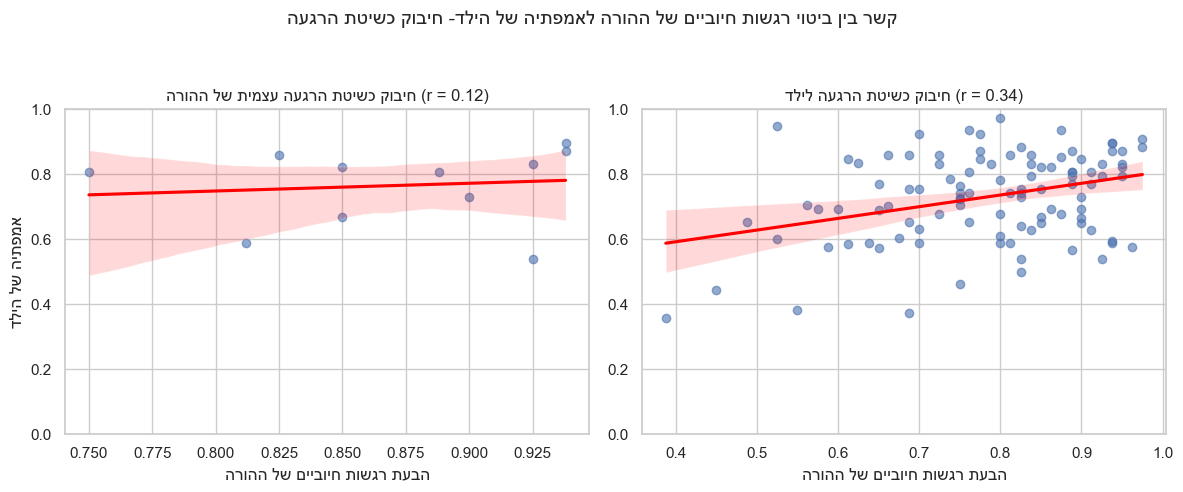

In [77]:
hug_df1 = df[df["dominant_method_self"].str.contains("חיבוק", na=False)]
hug_df2 = df[df["dominant_method"].str.contains("חיבוק/מגע", na=False)]

corr_hug1 = hug_df1["child_empathy"].corr(hug_df1["parents emotional expersivness-positive"])
corr_hug2 = hug_df2["child_empathy"].corr(hug_df2["parents emotional expersivness-positive"])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.regplot(data=hug_df1,x="parents emotional expersivness-positive",y="child_empathy",ax=axes[0],scatter_kws={"alpha": 0.6},line_kws={"color": "red"})
axes[0].set_title(f"{reshape_text('חיבוק כשיטת הרגעה עצמית של ההורה')} (r = {corr_hug1:.2f})")
axes[0].set_xlabel(reshape_text("הבעת רגשות חיוביים של ההורה"))
axes[0].set_ylabel(reshape_text("אמפתיה של הילד"))
axes[0].set_ylim(0, 1)


sns.regplot(data=hug_df2,x="parents emotional expersivness-positive",y="child_empathy",ax=axes[1],scatter_kws={"alpha": 0.6},line_kws={"color": "red"})
axes[1].set_title(f"{reshape_text('חיבוק כשיטת הרגעה לילד')} (r = {corr_hug2:.2f})")
axes[1].set_xlabel(reshape_text("הבעת רגשות חיוביים של ההורה"))
axes[1].set_ylabel("")
axes[1].set_ylim(0, 1)


plt.suptitle(reshape_text("קשר בין ביטוי רגשות חיוביים של ההורה לאמפתיה של הילד- חיבוק כשיטת הרגעה"), fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

<div dir='rtl'>
בהשוואה בין שני הגרפים ניתן לראות כי הקשר בין הבעת רגשות חיוביים של ההורה לבין האמפתיה של הילד חזק יותר כאשר ההורה משתמש בשיטת ההרגעה חיבוק כלפי הילד שלו ישירות.
</div>

<div dir='rtl'>
כעת נבדוק את התתפלגות בין ההורים שהשתמשו בחיבוק כשיטת הרגעה עצמית וכשיטת הרגעה לילדיהם.
</p>

In [78]:
df["hug_child"] = df["dominant_method"].fillna("").str.contains("חיבוק/מגע") #אם יש ערכים חסרים זה מחזיר שגיאה ולכן fill
df["hug_self"] = df["dominant_method_self"].fillna("").str.contains("חיבוק") #כנ"ל

summary = df.groupby(["hug_child", "hug_self"]).size().reset_index(name="count") #בודק כמה יש לקבוצה

summary["hug_child"] = summary["hug_child"].map({True: "חיבוק/מגע לילד",False: "ללא חיבוק/מגע לילד"})
summary["hug_self"] = summary["hug_self"].map({True: "חיבוק כשיטת הרגעה עצמית",False: "ללא חיבוק כשיטת הרגעה עצמית"})
labels = list(pd.unique(pd.Series(summary["hug_child"].tolist() + summary["hug_self"].tolist())))

label_to_index = {label: i for i, label in enumerate(labels)}

summary["source_index"] = summary["hug_child"].map(label_to_index)
summary["target_index"] = summary["hug_self"].map(label_to_index)

fig = go.Figure(data=[go.Sankey(node=dict(pad=15,thickness=30,line=dict(color="black", width=0.5),label=labels),link=dict(source=summary["source_index"],target=summary["target_index"],value=summary["count"]))])
fig.update_layout(title=dict(text="התפלגות השימוש בחיבוק להרגעת הילד לבין שימוש בו כשיטת הרגעה עצמית",x=0.5) ,font_size=14,width=1200,height=400)

fig.show()


<div dir='rtl'>
ניתן לראות כי רוב ההורים, בין אם בחרו בחיבוק כאסטרטגיית הרגעה עצמית ובין אם לא, נוטים להשתמש בחיבוק ובמגע כלפי ילדיהם. עם זאת, קיימת חפיפה חלקית בלבד בין הורים שמרגיעים את ילדיהם באמצעות חיבוק לבין הורים שעושים שימוש בחיבוק גם כלפי עצמם.
</div>


<div dir='rtl'>
בשלב זה נבחן האם קיימים הבדלים ברמת האמפתיה של הילד וברמת ההבעה הרגשית החיובית של ההורה, תוך התמקדות בהורים שעשו שימוש בחיבוק כשיטת הרגעה – בין הקבוצות:
    <br>
1. הורים שבחרו בחיבוק המופנה לילד בלבד 
    <br>
2. הורים שבחרו בחיבוק המופנה גם לילד וגם לעצמם
</p>

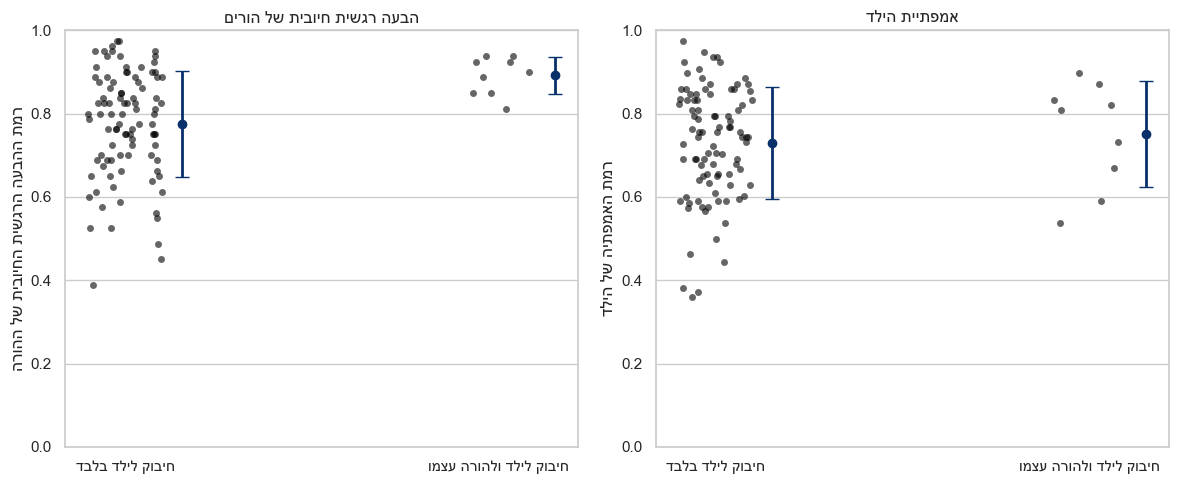

In [79]:
df["hug_combined"] = "nan" 
df.loc[(df["hug_child"] == True) & (df["hug_self"] == False), "hug_combined"] = "חיבוק לילד בלבד"
df.loc[(df["hug_child"] == True) & (df["hug_self"] == True),  "hug_combined"] = "חיבוק לילד ולהורה עצמו"
df["hug_combined_reshaped"] = df["hug_combined"].apply(reshape_text)
df_hugs = df[df["hug_combined"].isin(["חיבוק לילד בלבד", "חיבוק לילד ולהורה עצמו"])].copy()
df_hugs = df_hugs.dropna(subset=["hug_combined_reshaped", "parents emotional expersivness-positive", "child_empathy"])

x_order = df_hugs["hug_combined_reshaped"].unique() 
x_offset = 0.15

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

sns.stripplot(data=df_hugs,x="hug_combined_reshaped",y="parents emotional expersivness-positive",jitter=True,alpha=0.6,ax=axes[0],color='black',order=x_order)

means = df_hugs.groupby("hug_combined_reshaped")["parents emotional expersivness-positive"].mean()
stds = df_hugs.groupby("hug_combined_reshaped")["parents emotional expersivness-positive"].std()

for i, category in enumerate(x_order):
    mean = means[category]
    std = stds[category]
    axes[0].errorbar(x=i + x_offset,y=mean,yerr=std,fmt='o',color='#08306b',capsize=5,elinewidth=2)

axes[0].set_title(reshape_text("הבעה רגשית חיובית של הורים"))
axes[0].set_ylabel(reshape_text("רמת ההבעה הרגשית החיובית של ההורה"))
axes[0].set_xlabel("")
axes[0].set_xticks(range(len(x_order)))
axes[0].set_xticklabels(x_order)
axes[0].set_ylim(0, 1)


sns.stripplot(data=df_hugs,x="hug_combined_reshaped",y="child_empathy",jitter=True,alpha=0.6,ax=axes[1],color='black',order=x_order)

means = df_hugs.groupby("hug_combined_reshaped")["child_empathy"].mean()
stds = df_hugs.groupby("hug_combined_reshaped")["child_empathy"].std()

for i, category in enumerate(x_order):
    mean = means[category]
    std = stds[category]
    axes[1].errorbar(x=i + x_offset,y=mean,yerr=std,fmt='o',color='#08306b',capsize=5,elinewidth=2)

axes[1].set_title(reshape_text("אמפתיית הילד"))
axes[1].set_ylabel(reshape_text("רמת האמפתיה של הילד"))
axes[1].set_xlabel("")
axes[1].set_xticks(range(len(x_order)))
axes[1].set_xticklabels(x_order)
axes[1].set_ylim(0, 1)


plt.tight_layout()
plt.show()


<div dir='rtl'>
  <strong>מסקנות מהגרפים:</strong>
  <ul>
    <li><strong>הבעה רגשית חיובית של ההורים:</strong> 
      <ul><ul style="list-style-type: circle; padding-right: 20px;">
        <li>הורים שחיבקו גם את עצמם וגם את הילד הראו ממוצע גבוה יותר של הבעה רגשית חיובית לעומת אלו שחיבקו רק את הילד.</li>
        <li>סטיית התקן בקבוצת "חיבוק לילד בלבד" הייתה גבוהה יותר – מה שמעיד על פיזור רחב יותר בתגובות הרגשיות של ההורים.</li>
      </ul>
    </li>
    <li><strong>אמפתיית הילד:</strong> 
      <ul> <ul style="list-style-type: circle; padding-right: 20px;">
        <li>ממוצע האמפתיה בקרב ילדים שההורה חיבק רק אותם לבין ילדים אשר הוריהם השתמשו בחיבוק גם עבור ילדיהם וגם עבור עצמם כמעט זהה.</li>
      </ul>
    </li>
  </ul>
</div>
      <ul style="list-style-type: circle; padding-right: 20px;">



<div dir='rtl'>
  <strong>מסקנה כללית:</strong>
  <ul>
    <li>תחילה נמצא כי קיים הבדל משמעותי בעוצמת הקשר בין אמפתיית הילד לבין הבעת רגשות חיוביים של ההורה, בהתאם לשימוש בחיבוק כשיטת הרגעה – כאשר הקשר היה חזק יותר כאשר החיבוק הופנה כלפי הילד.</li>
    <li>בהמשך נמצא כי קיימת חפיפה חלקית בלבד בין הורים שמרגיעים את ילדיהם באמצעות חיבוק לבין הורים שעושים בו שימוש גם להרגעה עצמית. למרות שמדובר במדגם קטן (כ־10%), ניתן לראות כי ילדים של הורים שהשתמשו בחיבוק לשני הכיוונים הראו רמות אמפתיה דומות, אך ההורים עצמם הפגינו הבעת רגשות חיוביים גבוהה יותר.</li>
  </ul>
</div>


<h2 style="color: #345682">🗞️ Emotional Impact of Parental News Consumption</h2>

<div dir='rtl'>
בחלק זה בחרנו להתמקד בשאלה – כיצד החשיפה לחדשות משפיעה על מדדים רגשיים בקרב הורים וילדים:
<br>
הניתוח כולל שלושה מוקדים עיקריים:
</div>

<div dir='rtl'>
<ul>
   <li>התפלגות רמת החשיפה לחדשות לבין האווירה הרגשית בבית כפי שהיא נתפסת על ידי ההורים.</li>
   <li>התפלגות וממוצע וויסות רגשות שליילים בקרב הורים ע"פ חלוקה לרמת חשיפה</li>
  <li>השפעת רמת החשיפה לחדשות על רגשות חיוביים ואמפתיה בקרב ילדים, תוך הבחנה בין קבוצות גיל.</li>
</ul>
</div>

<div dir='rtl'>
  <strong style="font-size: 18px;">התפלגות רמת החשיפה לחדשות על האווירה בבית</strong>
</div>

<div dir='rtl'>
במטרה לבחון האם רמות החשיפה של ההורים לחדשות משפיעה על האווירה הכללית בבית בתקופת המלחמה, נבנה תרשים Sankey המציג את ההתפלגות בין רמות החשיפה לחדשות לבין קטגוריות של האווירה הכללית שדווחה בבית. 
<br>
התרשים מראה האם הורים שהעידו כי צרכו הרבה בחדשות במהלך המלחמה גם העידו שהאווירה בביתהם מתוחה.
</div>

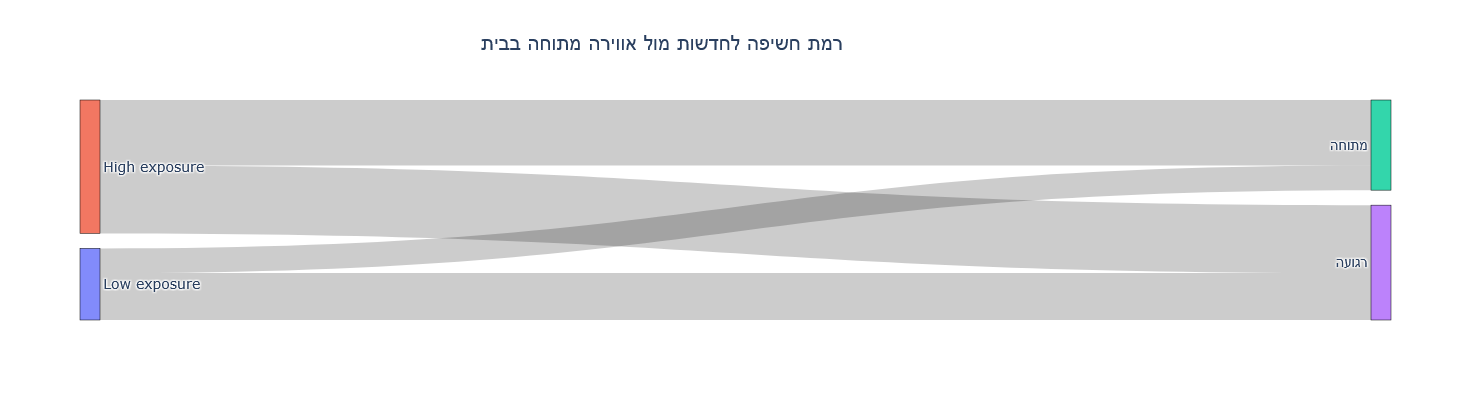

In [80]:
df_sankey = df[['news_freq_level', 'home_atmosphere_cat']].dropna()
labels = pd.unique(pd.concat([df_sankey['news_freq_level'], df_sankey['home_atmosphere_cat']])).tolist()
label_map = {label: i for i, label in enumerate(labels)}
link_df = df_sankey.groupby(['news_freq_level', 'home_atmosphere_cat']).size().reset_index(name='count')
source = link_df['news_freq_level'].map(label_map)
target = link_df['home_atmosphere_cat'].map(label_map)
value = link_df['count']
fig = go.Figure(data=[go.Sankey(node=dict(pad=15,thickness=20,line=dict(color="black", width=0.5),label=labels),link=dict(source=source,target=target,value=value))])

fig.update_layout(title_text='רמת חשיפה לחדשות מול אווירה מתוחה בבית', title_x=0.45 ,font_size=14,width=1200,height=400)
fig.show()


<div dir='rtl'>
תרשים ה־Sankey מציג כי מבין ההורים אשר העידו כי האווירה בביתהם מתוחה, חשיפתם לחדשות הייתה גבוהה יותר אך גם רוב האנשים שהעידו כי האווירה בביתהם רגועה העידו כי חשיפתם לחדשות הייתה גבוהה.  
</div>

<div dir='rtl'>
  <strong style="font-size: 18px;">התפלגות וממוצע וויסות רגשות שליילים בקרב הורים ע"פ חלוקה לרמת חשיפה</strong>
</div>

C:\Users\lihin\AppData\Local\Temp\ipykernel_74816\3024671101.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




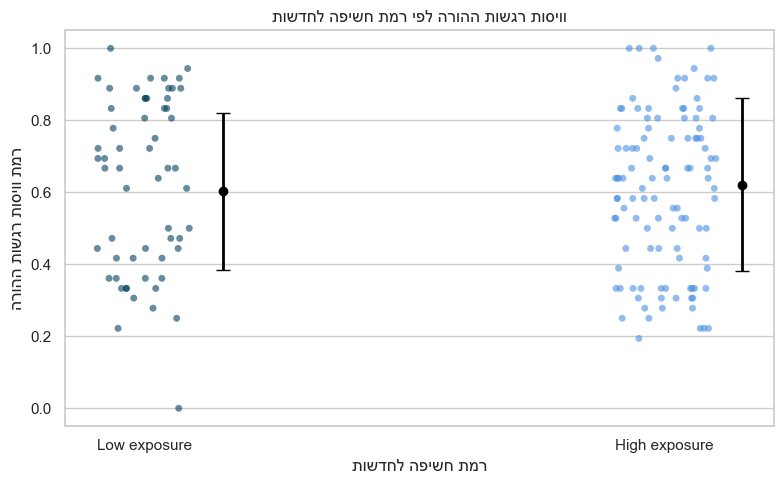

In [81]:
fig, ax = plt.subplots(figsize=(8, 5))
plot_data = df[df['news_freq_level'].isin(['High exposure', 'Low exposure'])].copy()
label_map = {'High exposure': 'High exposure', 'Low exposure':'Low exposure'}
plot_data['news_freq_level_heb'] = plot_data['news_freq_level'].map(label_map)

sns.stripplot(data=plot_data,x='news_freq_level_heb',y='parent emotion regulation-reappraisel',jitter=True,alpha=0.6,palette=['#003f5c', '#4a90e2'],ax=ax)

means = plot_data.groupby('news_freq_level_heb')["parent emotion regulation-reappraisel"].mean()
stds = plot_data.groupby('news_freq_level_heb')["parent emotion regulation-reappraisel"].std()
x_offset = 0.15
for i, category in enumerate(means.index):
    ax.errorbar(i + x_offset, means[category], yerr=stds[category],
                fmt='o', color='black', capsize=5, elinewidth=2)

ax.set_title(reshape_text("וויסות רגשות ההורה לפי רמת חשיפה לחדשות"))
ax.set_ylabel(reshape_text("רמת וויסות רגשות ההורה"))
ax.set_xlabel(reshape_text("רמת חשיפה לחדשות"))
plt.tight_layout()
plt.show()


<div dir="rtl">
ההורים, בין אם נחשפו רבות לחדשות ובין אם לא, מדווחים על רמות דומות של וויסות רגשות. ניתן לראות כי הפיזור רחב בשתי הקבוצות – הן בקרב הורים עם חשיפה גבוהה והן עם חשיפה נמוכה – ולכן לא ניתן להסיק מסקנה חד־משמעית על השפעת רמת החשיפה על וויסות רגשות ההורים.
</div>


<div dir='rtl'>
  <strong style="font-size: 18px;">השפעת רמת חשיפה לחדשות על רגשות חיוביים ואמפתיה בקרב ילדים – לפי קבוצות גיל</strong>
</div>
<div dir='rtl'>
הגרפים הלה מציגים את ממוצעי הרגשות החיוביים והאמפתיה של ילדים, תוך הצלבה בין קבוצות גיל שונות לבין רמות החשיפה של ההורים לחדשות. 
<br>
מטרת הניתוח היא לזהות מגמות של השפעה עקיפה של רמת צריכת החדשות של ההורה על התפקוד הרגשי של הילד, ובהתאם לכך לבדוק האם קיימים הבדלים מובהקים בין קבוצות הגיל השונות.
</div>


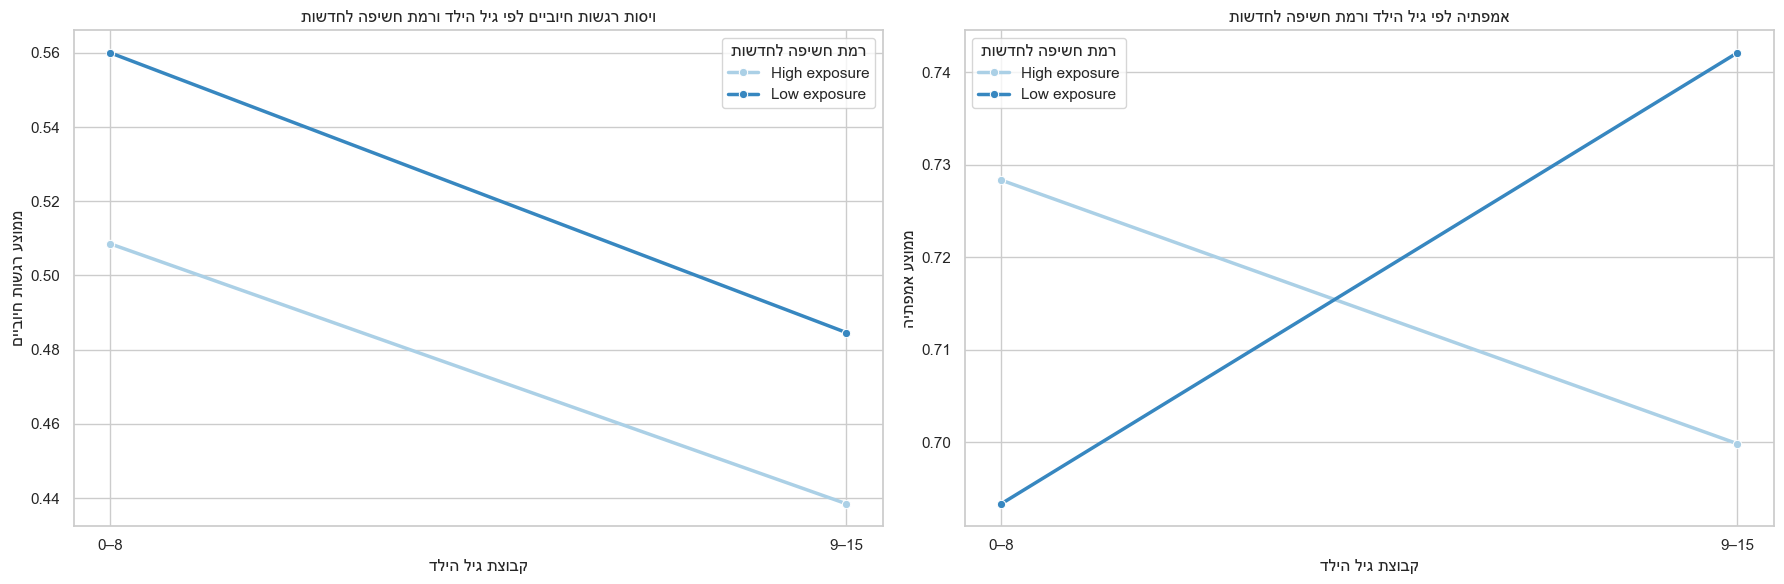

In [82]:
notna_df = df[df["news_freq_level"].notna() & df["child emotion regulation-positive"].notna() & df["child_empathy"].notna()].copy()
grouped = notna_df.groupby(["age_group_child_label", "news_freq_level"],observed=True).agg({"child emotion regulation-positive": "mean","child_empathy": "mean"}).reset_index()

palette_blues = sns.color_palette("Blues", n_colors=2)
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharex=True)

sns.lineplot(data=grouped,x="age_group_child_label",y="child emotion regulation-positive",hue="news_freq_level",marker="o",palette=palette_blues,ax=axes[0],linewidth=2.5)
axes[0].set_title(reshape_text("ויסות רגשות חיוביים לפי גיל הילד ורמת חשיפה לחדשות"))
axes[0].set_xlabel(reshape_text("קבוצת גיל הילד"))
axes[0].set_ylabel(reshape_text("ממוצע רגשות חיוביים"))
axes[0].legend(title=reshape_text("רמת חשיפה לחדשות"))

sns.lineplot(data=grouped,x="age_group_child_label",y="child_empathy",hue="news_freq_level",marker="o",palette=palette_blues,ax=axes[1],linewidth=2.5)
axes[1].set_title(reshape_text("אמפתיה לפי גיל הילד ורמת חשיפה לחדשות"))
axes[1].set_xlabel(reshape_text("קבוצת גיל הילד"))
axes[1].set_ylabel(reshape_text("ממוצע אמפתיה"))
axes[1].legend(title=reshape_text("רמת חשיפה לחדשות"))

plt.tight_layout()
plt.show()


<div dir="rtl" style="text-align:right; font-family:Arial; line-height:1.8;">

<table border="1" cellpadding="8" cellspacing="0" style="border-collapse: collapse; margin-bottom: 20px; width: 100%; text-align: center;">
<thead style="background-color: #f0f0f0;">
<tr>
<th>קבוצת גיל הילד</th>
<th>רגשות חיוביים</th>
<th>אמפתיה</th>
</tr>
</thead>
<tbody>
<tr>
<td><b>0–8</b></td>
<td>ילדים שהוריהם נחשפו יותר לחדשות הפגינו רמה נמוכה יותר של ממוצע וויסות רגשות חיוביים</td>
<td>ילדים שהוריהם נחשפו יותר לחדשות הפגינו רמת אמפתיה גבוהה יותר</td>
</tr>
<tr>
<td><b>9–15</b></td>
<td>ירידה חדה - ישנו הבדל בין רמות החשיפה, ילדים להורים שנחשפו יותר לחדשות הראו פחות רגשות חיוביים</td>
<td>הבדל משמעותי - גרפים הפוכים:חלה ירידה באמפתיה בקרב ילדהים להורים שנחשפו יותר לעומת לעומת עלייה באמפתיה בקרב ילדים שהוריהם נחשפו פחות.</td>
</tr>
</tbody>
</table>

</div>


<div dir='rtl'>
    <strong>מסקנות:</strong>
<br>
<strong>וויסות רגשות חיוביים:</strong> ילדים שהוריהם נחשפו פחות לחדשות הפגינו רמות גבוהות יותר של רגשות חיוביים – באופן עקבי בכל קבוצות הגיל.
<br>
<strong>אמפתיה:</strong> בגרף זה ניתן לראות כי בקרב ילדים צעירים, חשיפה גבוהה לחדשות מצד ההורים נקשרה לאמפתיה גבוהה יותר, אך בקרב ילדים בוגרים ההשפעה התהפכה: חשיפה נמוכה לחדשות הייתה קשורה לרמות אמפתיה גבוהות יותר.
</div>

<div dir="rtl">
<strong>מסקנות כוללות:</strong>
<br>
למרות שלא נמצא הבדל משמעותי ברמת הוויסות הרגשי בין הורים שנחשפו רבות לחדשות לבין אלו שנחשפו פחות, נמצא קשר ברור בין רמת החשיפה לבין תפיסת האווירה בבית – כאשר חשיפה גבוהה לחדשות נטתה להיות מלווה באווירה מתוחה יותר.
<br>
ההשפעה המורכבת של החשיפה לחדשות באה לידי ביטוי גם ברווחת הילד. ילדים להורים עם חשיפה גבוהה הציגו רמות נמוכות יותר של רגשות חיוביים, בעיקר בגילאים הבוגרים (9–15). באשר לאמפתיה, נמצא דפוס מעניין: בגיל הרך (0–8), חשיפה גבוהה של ההורה דווקא נקשרה לרמות אמפתיה גבוהות יותר בקרב הילדים. לעומת זאת, בגילאים הבוגרים, אותה חשיפה נקשרה לירידה ברמת האמפתיה של הילדים.

</div>


<h2 style="color: #345682">Appendices:</h2>

<div dir='rtl'>
במהלך העבודה השתמשנו בכלים הבאים:
<br>
1. chatGPT - עיצוב הגרפים, היכרות עם גרף ענן המילים ו-snaky, שימוש בספריית ערבית ועזרה ביצירת הפונקציה שהשמישה אותו על מנת להפוך את הכתב, עיצוב כללי של הפרוייקט וכתיבה ב-HTML. 
<br>
2. pandas - למדנו כיצד עובדים עם דאטא שיש בו ערכים חסרים, התעמקות עם פונקציות שלא היכרנו והצאט עזר לנו במציאת דרך ביצוע (דוג-replace, pivot).
<br>
3. google - חיפשנו אמירות מחקריות שתומכות בממצאים שלנו מבחינה פסיכולוגית (לעיתים גם נעזרנו בצ'אט).
</div>